# 01 — Exploratory Data Analysis

Our task is to explore the electricity and gas data and prepare it for a first fraud-classification model.

We will look at the two tables, check whether the data makes sense, and create one row per client for later modelling. The invoice table is large, so it is processed in chunks instead of loading everything at once.

Run the notebook from top to bottom. Stop at the discussion prompts, talk through them with your group, and write down what you notice. The data is read from Parquet files; the optional output is a smaller CSV with one row per client.

## Business Case

Imagine that a utility company has a small team that can inspect only some clients. We want to help them decide which clients to inspect first.

- We will start with **average precision (PR-AUC)** as our main metric.
- We will also look at **precision** and **recall**. We will use a `k`, which means the number of clients the team can inspect.
- Later, we can also use ROC-AUC, a confusion matrix, and results for different groups of clients.

Before choosing a final model, we ask: 
- How many inspections are possible?
- What does an inspection cost?
- What is the cost of missing fraud or falsely accusing a customer?
These answers help us choose a `k` and a prediction threshold later.

For now, use the charts to ask good questions. A difference between fraud and non-fraud clients does not automatically explain why fraud happens.

## Imports and constants

In the next cell we import the libraries used in this notebook and define the file locations and settings. `TEST_SIZE = 0.20` means 20% of clients will go into `df_test`. `CHUNK_SIZE` controls how many invoice rows are handled at one time. You normally do not need to change these values.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pyarrow.parquet as pq
from IPython.display import display
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PARQUET_DIR = DATA_DIR / "parquet"
CHUNK_SIZE = 250_000
SAVE_FEATURES = False
AS_OF_DATE = None  # Example: "2018-12-31"; required for a real deployment backtest.
TEST_SIZE = 0.20
RSEED = 42

required_files = [PARQUET_DIR / "client_train.parquet", PARQUET_DIR / "invoice_train.parquet"]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required files: {missing_files}.")

print(f"Using Parquet data from: {PARQUET_DIR.resolve()}")

Using Parquet data from: /Users/skress/Documents/spiced/ml_project/ds-fraud-in-electricity-and-gas/data/parquet


## Step 1 - Understand the data

`client_train.parquet` has one row per client and contains the target. `invoice_train.parquet` has many invoices for each client. Before we model, we need to understand how these tables fit together.

The relationship is **one client to many invoices**. Client columns describe the customer. Invoice columns describe readings and consumption over time. For our first model, we turn the invoices into summaries for each client, for example: number of invoices, average consumption, zero-consumption rate, and whether the invoices are electricity or gas.

Think about this with your group: why would it be a problem to split invoice rows into train and test data before aggregating them?

### Load clients and make the train/test split

This cell loads the complete client table, checks its basic shape, and then makes the two DataFrames used in the project: `df_train` and `df_test`. `stratify=client["target"]` keeps the fraud percentage similar in both DataFrames. We split clients here, before exploring patterns, so `df_test` can stay unseen until the final model evaluation.

In [2]:
client = pd.read_parquet(PARQUET_DIR / "client_train.parquet")
client["client_id"] = client["client_id"].astype("string")
client["creation_date"] = pd.to_datetime(client["creation_date"], dayfirst=True, errors="raise")
client["target"] = client["target"].astype("int8")

client_overview = pd.DataFrame({
    "rows": [len(client)],
    "unique_clients": [client["client_id"].nunique()],
    "duplicate_rows": [client.duplicated().sum()],
    "missing_cells": [int(client.isna().sum().sum())],
    "fraud_rate": [client["target"].mean()],
})
display(client_overview)
display(client.head())
display(client.dtypes.rename("dtype").to_frame())

assert client["client_id"].is_unique, "Expected one row per client."
assert set(client["target"].unique()) <= {0, 1}, "Target must be binary."

# Stratified train-test split
df_train, df_test = train_test_split(
    client,
    test_size=TEST_SIZE,
    random_state=RSEED,
    stratify=client["target"],
)

# Keep the IDs so the later merge cell can safely rebuild each split if we run it again.
train_client_ids = df_train["client_id"].copy()
test_client_ids = df_test["client_id"].copy()

,rows,unique_clients,duplicate_rows,missing_cells,fraud_rate
0,135493,135493,0,0,0.055841


,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,1994-12-31,0
1,69,train_Client_1,11,107,2002-05-29,0
2,62,train_Client_10,11,301,1986-03-13,0
3,69,train_Client_100,11,105,1996-07-11,0
4,62,train_Client_1000,11,303,2014-10-14,0


,dtype
disrict,int16
client_id,string
client_catg,int16
region,int16
creation_date,datetime64[us]
target,int8


### Missing values in all client rows

This check uses the complete `client` table, not only `df_train`. A zero means that column has no missing values. This is a raw-data check: it tells us whether values are empty (`NaN`), but it does not tell us whether a value is unusual or unrealistic.

In [3]:
# Check for missing values in the complete client data
# This happens before EDA, so we see the real state of the supplied data.
display(client.isna().sum().rename("missing_values").to_frame())

,missing_values
disrict,0
client_id,0
client_catg,0
region,0
creation_date,0
target,0


### Check the split

This shows the number of clients and the target counts in `df_train` and `df_test`. The fraud share should be very similar in both tables. It is only a check that the stratified split worked; it does not use invoice information.

In [4]:
# Print the shape of the two DataFrames
print("Train data")
print("# df_train: {}".format(df_train.shape[0]))
print("==================")
print("Test data")
print("# df_test: {}".format(df_test.shape[0]))

display(pd.crosstab(df_train["target"], columns="train", margins=True))
display(pd.crosstab(df_test["target"], columns="test", margins=True))

Train data
# df_train: 108394
Test data
# df_test: 27099


col_0,train,All
target,,
0,102341,102341
1,6053,6053
All,108394,108394


col_0,test,All
target,,
0,25586,25586
1,1513,1513
All,27099,27099


## Step 2 - EDA Part

### Check for missing values

The source column names `disrict` and `counter_statue` are misspelled. We keep them as they are so that the notebook matches the supplied data.

The code below reads the complete invoice file in smaller batches. This matters because there are millions of invoices and loading all of them at once can crash a notebook kernel. The missing-value result still covers every invoice row, not a sample.

### First look at invoice rows

The full invoice table is too large to display. This cell reads a small sample so we can see the column names, example values, and data types. `counter_statue` and `counter_type` are text categories: they describe a status or meter type, not an amount that can sensibly be averaged.

In [5]:
invoice_parquet = pq.ParquetFile(PARQUET_DIR / "invoice_train.parquet")
invoice_sample = invoice_parquet.read_row_group(0).to_pandas().head(5_000)
invoice_sample["invoice_date"] = pd.to_datetime(invoice_sample["invoice_date"], errors="raise")
display(invoice_sample.head())
display(invoice_sample.dtypes.rename("inferred_dtype").to_frame())
print(f"Sample shape: {invoice_sample.shape}")

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


,inferred_dtype
client_id,str
invoice_date,datetime64[us]
tarif_type,int16
counter_number,int64
counter_statue,str
counter_code,int16
reading_remarque,int16
counter_coefficient,int16
consommation_level_1,int64
consommation_level_2,int64


Sample shape: (5000, 16)


### Create one row per client

The next cell defines a function; it does not run the full calculation yet. The function reads every invoice in small batches and builds client summaries such as invoice count, first and last invoice date, consumption totals, zero-consumption rate, electricity/gas share, and the average/longest gap between invoices. It also counts missing values across the complete invoice table.

We need this because the target is stored once per client, while the invoice table has many rows per client. A model needs one consistent row per client.

In [6]:
CONSUMPTION_COLUMNS = [f"consommation_level_{level}" for level in range(1, 5)]

def aggregate_invoices(path, chunk_size=250_000, as_of_date=None):
    partials = []
    row_hashes = []
    missing_counts = None
    status_counts = pd.Series(dtype="int64")
    tariff_counts = pd.Series(dtype="int64")
    source_rows = 0
    total_rows = 0
    excluded_after_cutoff = 0
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None
    started = time.perf_counter()

    parquet_file = pq.ParquetFile(path)
    reader = parquet_file.iter_batches(batch_size=chunk_size)

    for chunk_number, batch in enumerate(reader, start=1):
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["counter_statue"] = chunk["counter_statue"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        source_rows += len(chunk)
        # Count missing values before any optional date filtering.
        # This is the missing-value check for the complete invoice data.
        chunk_missing = chunk.isna().sum()
        missing_counts = chunk_missing if missing_counts is None else missing_counts.add(chunk_missing, fill_value=0)
        if cutoff is not None:
            after_cutoff = chunk["invoice_date"].gt(cutoff)
            excluded_after_cutoff += int(after_cutoff.sum())
            chunk = chunk.loc[~after_cutoff].copy()
        total_rows += len(chunk)
        row_hashes.append(pd.util.hash_pandas_object(chunk, index=False).to_numpy())
        status_counts = status_counts.add(chunk["counter_statue"].value_counts(), fill_value=0)
        tariff_counts = tariff_counts.add(chunk["tarif_type"].value_counts(), fill_value=0)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["zero_consumption"] = chunk["total_consumption"].eq(0).astype("int8")
        chunk["is_elec"] = chunk["counter_type"].eq("ELEC").astype("int8")
        chunk["is_gaz"] = chunk["counter_type"].eq("GAZ").astype("int8")
        chunk["index_went_backwards"] = chunk["index_delta"].lt(0).astype("int8")
        # months_number is the billing-period length. Values above 24 are implausible here,
        # so exclude them only from the per-month calculation, not from the raw data.
        chunk["valid_billing_months"] = chunk["months_number"].between(1, 24)
        chunk["billed_months"] = chunk["months_number"].where(chunk["valid_billing_months"])
        chunk["index_delta_for_valid_months"] = chunk["index_delta"].where(chunk["valid_billing_months"])
        chunk["is_four_month_bill"] = chunk["months_number"].eq(4).astype("int8")

        grouped = chunk.groupby("client_id", observed=True).agg(
            invoice_count=("client_id", "size"),
            first_invoice=("invoice_date", "min"),
            last_invoice=("invoice_date", "max"),
            total_consumption_sum=("total_consumption", "sum"),
            total_consumption_max=("total_consumption", "max"),
            index_delta_sum=("index_delta", "sum"),
            index_delta_min=("index_delta", "min"),
            index_delta_max=("index_delta", "max"),
            months_sum=("months_number", "sum"),
            zero_consumption_count=("zero_consumption", "sum"),
            elec_invoice_count=("is_elec", "sum"),
            gaz_invoice_count=("is_gaz", "sum"),
            backwards_index_count=("index_went_backwards", "sum"),
            valid_billing_invoice_count=("valid_billing_months", "sum"),
            billed_months_sum=("billed_months", "sum"),
            index_delta_valid_months_sum=("index_delta_for_valid_months", "sum"),
            four_month_bill_count=("is_four_month_bill", "sum"),
        )
        partials.append(grouped.reset_index())
        if chunk_number % 5 == 0:
            print(f"Processed {total_rows:,} invoice rows...")

    partial = pd.concat(partials, ignore_index=True)
    client_agg = partial.groupby("client_id", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        first_invoice=("first_invoice", "min"),
        last_invoice=("last_invoice", "max"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        total_consumption_max=("total_consumption_max", "max"),
        index_delta_sum=("index_delta_sum", "sum"),
        index_delta_min=("index_delta_min", "min"),
        index_delta_max=("index_delta_max", "max"),
        months_sum=("months_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
        elec_invoice_count=("elec_invoice_count", "sum"),
        gaz_invoice_count=("gaz_invoice_count", "sum"),
        backwards_index_count=("backwards_index_count", "sum"),
        valid_billing_invoice_count=("valid_billing_invoice_count", "sum"),
        billed_months_sum=("billed_months_sum", "sum"),
        index_delta_valid_months_sum=("index_delta_valid_months_sum", "sum"),
        four_month_bill_count=("four_month_bill_count", "sum"),
    )

    # Calculate date gaps for each client. Invoice rows are stored together
    # by client in this Parquet file, so only one client's dates need to be
    # kept in memory at a time.
    gap_rows = []
    closed_client_ids = set()
    current_client_id = None
    current_date_parts = []

    def finish_current_client():
        if current_client_id is None:
            return
        dates = np.sort(np.concatenate(current_date_parts))
        if len(dates) < 2:
            gap_rows.append({
                "client_id": current_client_id,
                "invoice_gap_count": 0,
                "mean_invoice_gap_days": 0.0,
                "max_invoice_gap_days": 0,
            })
            return
        gap_days = np.diff(dates).astype("timedelta64[D]").astype(int)
        gap_rows.append({
            "client_id": current_client_id,
            "invoice_gap_count": len(gap_days),
            "mean_invoice_gap_days": gap_days.mean(),
            "max_invoice_gap_days": gap_days.max(),
        })

    gap_reader = pq.ParquetFile(path).iter_batches(
        batch_size=chunk_size,
        columns=["client_id", "invoice_date"],
    )
    for gap_batch in gap_reader:
        gap_frame = gap_batch.to_pandas()
        gap_frame["invoice_date"] = pd.to_datetime(gap_frame["invoice_date"], errors="raise")
        for client_id, group in gap_frame.groupby("client_id", sort=False):
            client_dates = group["invoice_date"].dropna().to_numpy(dtype="datetime64[ns]")
            if current_client_id is None:
                current_client_id = client_id
                current_date_parts = [client_dates]
            elif client_id == current_client_id:
                current_date_parts.append(client_dates)
            else:
                finish_current_client()
                closed_client_ids.add(current_client_id)
                if client_id in closed_client_ids:
                    raise ValueError("Invoice rows are not grouped by client; cannot calculate gaps safely.")
                current_client_id = client_id
                current_date_parts = [client_dates]
    finish_current_client()

    gap_features = pd.DataFrame(gap_rows)
    client_agg = client_agg.merge(gap_features, on="client_id", how="left", validate="one_to_one")

    client_agg["mean_consumption"] = client_agg["total_consumption_sum"] / client_agg["invoice_count"]
    client_agg["mean_index_delta"] = client_agg["index_delta_sum"] / client_agg["invoice_count"]
    client_agg["mean_months"] = client_agg["months_sum"] / client_agg["invoice_count"]
    client_agg["zero_consumption_rate"] = client_agg["zero_consumption_count"] / client_agg["invoice_count"]
    client_agg["elec_share"] = client_agg["elec_invoice_count"] / client_agg["invoice_count"]
    client_agg["active_days"] = (client_agg["last_invoice"] - client_agg["first_invoice"]).dt.days
    client_agg["backwards_index_rate"] = client_agg["backwards_index_count"] / client_agg["invoice_count"]
    client_agg["mean_index_delta_per_billed_month"] = np.where(
        client_agg["billed_months_sum"].gt(0),
        client_agg["index_delta_valid_months_sum"] / client_agg["billed_months_sum"],
        np.nan,
    )
    client_agg["mean_billing_months"] = np.where(
        client_agg["valid_billing_invoice_count"].gt(0),
        client_agg["billed_months_sum"] / client_agg["valid_billing_invoice_count"],
        np.nan,
    )
    client_agg["four_month_bill_rate"] = client_agg["four_month_bill_count"] / client_agg["invoice_count"]
    client_agg["invoice_frequency_per_year"] = np.where(
        client_agg["active_days"].gt(0),
        client_agg["invoice_count"] / (client_agg["active_days"] / 365.25),
        0,
    )

    invoice_hashes = pd.Series(np.concatenate(row_hashes), copy=False)
    duplicate_row_hashes = invoice_hashes[invoice_hashes.duplicated(keep=False)].unique()
    audit = {
        "source_invoice_rows": source_rows,
        "invoice_rows": total_rows,
        "excluded_after_cutoff": excluded_after_cutoff,
        "duplicate_row_hash_matches": int(invoice_hashes.duplicated().sum()),
        "duplicate_row_hashes": duplicate_row_hashes,
        "invoice_clients": client_agg["client_id"].nunique(),
        "missing_by_column": missing_counts.sort_values(ascending=False),
        "counter_status_counts": status_counts.sort_index().astype("int64"),
        "tariff_counts": tariff_counts.sort_index().astype("int64"),
        "elapsed_seconds": time.perf_counter() - started,
    }
    return client_agg, audit

### Run the invoice aggregation

This is the longer-running cell. It processes every invoice, prints progress, and then shows the missing-value count for the complete invoice data. It also shows the values found in `counter_statue` and `tarif_type`. A result of zero missing values is useful, but still check unusual categories and extreme values later.

In [7]:
invoice_features, invoice_audit = aggregate_invoices(
    PARQUET_DIR / "invoice_train.parquet",
    chunk_size=CHUNK_SIZE,
    as_of_date=AS_OF_DATE,
)

print(f"Processed {invoice_audit['invoice_rows']:,} rows in {invoice_audit['elapsed_seconds']:.1f}s")
print("Missing values in the complete invoice data:")
display(invoice_features.head())
display(invoice_audit["missing_by_column"].rename("missing_values").to_frame())
display(invoice_audit["counter_status_counts"].rename("invoice_rows").to_frame())
display(invoice_audit["tariff_counts"].rename("invoice_rows").to_frame())

Processed 1,250,000 invoice rows...


Processed 2,500,000 invoice rows...


Processed 3,750,000 invoice rows...


Processed 4,476,749 rows in 8.2s
Missing values in the complete invoice data:


,client_id,invoice_count,first_invoice,last_invoice,total_consumption_sum,total_consumption_max,index_delta_sum,index_delta_min,index_delta_max,months_sum,zero_consumption_count,elec_invoice_count,gaz_invoice_count,backwards_index_count,valid_billing_invoice_count,billed_months_sum,index_delta_valid_months_sum,four_month_bill_count,invoice_gap_count,mean_invoice_gap_days,max_invoice_gap_days,mean_consumption,mean_index_delta,mean_months,zero_consumption_rate,elec_share,active_days,backwards_index_rate,mean_index_delta_per_billed_month,mean_billing_months,four_month_bill_rate,invoice_frequency_per_year
0,train_Client_0,35,2005-10-17,2019-03-19,12704,1386,12704,38,1386,162,0,35,0,0,35,162.0,12704.0,30,34,144.147059,508,362.971429,362.971429,4.628571,0.0,1.0,4901,0.0,78.419753,4.628571,0.857143,2.608396
1,train_Client_1,37,2005-10-19,2019-04-02,20629,1207,20629,190,1207,160,0,37,0,0,37,160.0,20629.0,31,36,136.472222,372,557.540541,557.540541,4.324324,0.0,1.0,4913,0.0,128.931250,4.324324,0.837838,2.750712
2,train_Client_10,18,2005-11-10,2019-05-02,15057,3082,15057,188,3082,116,0,18,0,0,18,116.0,15057.0,11,17,289.470588,738,836.5,836.5,6.444444,0.0,1.0,4921,0.0,129.801724,6.444444,0.611111,1.336009
3,train_Client_100,20,2005-06-10,2012-09-25,24,15,24,0,15,84,16,20,0,0,20,84.0,24.0,18,19,140.210526,442,1.2,1.2,4.2,0.8,1.0,2664,0.0,0.285714,4.200000,0.9,2.742117
4,train_Client_1000,14,2015-02-13,2019-06-17,12917,2382,12917,124,2382,52,0,14,0,0,14,52.0,12917.0,12,13,121.923077,301,922.642857,922.642857,3.714286,0.0,1.0,1585,0.0,248.403846,3.714286,0.857143,3.226183


,missing_values
client_id,0
invoice_date,0
tarif_type,0
counter_number,0
counter_statue,0
counter_code,0
reading_remarque,0
counter_coefficient,0
consommation_level_1,0
consommation_level_2,0


,invoice_rows
counter_statue,
0,4379008
1,74036
2,32
269375,1
3,258
4,2729
420,1
46,14
5,20639


,invoice_rows
tarif_type,
8,43
9,6039
10,276210
11,2679872
12,11345
13,11656
14,11611
15,72422
18,4


### Add invoice summaries to train and test

This cell joins the client-level invoice summaries onto both `df_train` and `df_test`. The checks show whether every invoice client belongs to the client table and whether any client has no invoices. The EDA below uses only `df_train`; `df_test` is prepared in the same way but not explored.

In [8]:
unknown_invoice_clients = set(invoice_features["client_id"]) - set(client["client_id"])
clients_without_invoices = set(client["client_id"]) - set(invoice_features["client_id"])
print(f"Invoice clients absent from client table: {len(unknown_invoice_clients):,}")
print(f"Clients without invoices: {len(clients_without_invoices):,}")

# Rebuild the original client-only splits before the merge.
# This makes this cell safe to run more than once: it never tries to add the same invoice features twice.
df_train = client.loc[client["client_id"].isin(train_client_ids)].copy()
df_test = client.loc[client["client_id"].isin(test_client_ids)].copy()

# Add the invoice summaries to both DataFrames.
# The client IDs were split before EDA and stay in their own DataFrame.
df_train = df_train.merge(
    invoice_features,
    on="client_id",
    how="left",
    validate="one_to_one",
)
df_test = df_test.merge(
    invoice_features,
    on="client_id",
    how="left",
    validate="one_to_one",
)
# Calculate customer tenure after merging because creation_date comes from client data and last_invoice comes from invoice data.
for frame in [df_train, df_test]:
    frame["customer_tenure_days_at_last_invoice"] = (
        frame["last_invoice"] - frame["creation_date"]
    ).dt.days

analysis = pd.concat([df_train, df_test], ignore_index=True)

assert len(analysis) == len(client)
assert not unknown_invoice_clients
display(df_train.head())
print(f"The EDA below uses df_train with {len(df_train):,} clients. df_test with {len(df_test):,} clients stays aside for later model evaluation.")

Invoice clients absent from client table: 0
Clients without invoices: 0


,disrict,client_id,client_catg,region,creation_date,target,invoice_count,first_invoice,last_invoice,total_consumption_sum,total_consumption_max,index_delta_sum,index_delta_min,index_delta_max,months_sum,zero_consumption_count,elec_invoice_count,gaz_invoice_count,backwards_index_count,valid_billing_invoice_count,billed_months_sum,index_delta_valid_months_sum,four_month_bill_count,invoice_gap_count,mean_invoice_gap_days,max_invoice_gap_days,mean_consumption,mean_index_delta,mean_months,zero_consumption_rate,elec_share,active_days,backwards_index_rate,mean_index_delta_per_billed_month,mean_billing_months,four_month_bill_rate,invoice_frequency_per_year,customer_tenure_days_at_last_invoice
0,60,train_Client_0,11,101,1994-12-31,0,35,2005-10-17,2019-03-19,12704,1386,12704,38,1386,162,0,35,0,0,35,162.0,12704.0,30,34,144.147059,508,362.971429,362.971429,4.628571,0.0,1.0,4901,0.0,78.419753,4.628571,0.857143,2.608396,8844
1,69,train_Client_1,11,107,2002-05-29,0,37,2005-10-19,2019-04-02,20629,1207,20629,190,1207,160,0,37,0,0,37,160.0,20629.0,31,36,136.472222,372,557.540541,557.540541,4.324324,0.0,1.0,4913,0.0,128.931250,4.324324,0.837838,2.750712,6152
2,69,train_Client_100,11,105,1996-07-11,0,20,2005-06-10,2012-09-25,24,15,24,0,15,84,16,20,0,0,20,84.0,24.0,18,19,140.210526,442,1.2,1.2,4.2,0.8,1.0,2664,0.0,0.285714,4.200000,0.9,2.742117,5920
3,62,train_Client_1000,11,303,2014-10-14,0,14,2015-02-13,2019-06-17,12917,2382,12917,124,2382,52,0,14,0,0,14,52.0,12917.0,12,13,121.923077,301,922.642857,922.642857,3.714286,0.0,1.0,1585,0.0,248.403846,3.714286,0.857143,3.226183,1707
4,62,train_Client_100000,11,309,2012-06-07,0,40,2012-11-23,2019-07-19,11463,1462,11463,0,1462,148,3,20,20,0,40,148.0,11463.0,31,39,62.282051,240,286.575,286.575,3.7,0.075,0.5,2429,0.0,77.452703,3.700000,0.775,6.014821,2598


The EDA below uses df_train with 108,394 clients. df_test with 27,099 clients stays aside for later model evaluation.


## Step 3 - Data Exploration

We explore `df_train` from here on. This lets us make decisions without looking at the test data first.

### Skewness of the features

Some clients have much larger consumption than others. We use a log scale in the charts so that those very large values do not hide the rest of the data. If you see a useful difference, ask whether that information would really be available before an inspection takes place.

### Look at the feature distributions

This cell makes one histogram for each client-level feature using `df_train`. Blue is non-fraud and red is fraud, so we can compare the two groups directly. The values are shown on a log scale because consumption, invoice counts, and invoice gaps are very uneven. Fraud is drawn with a stronger, less transparent line because it is the much smaller group. Look for long tails, many zero values, and features where the red shape differs from the blue shape. The table underneath compares the median and mean for fraud and non-fraud clients.

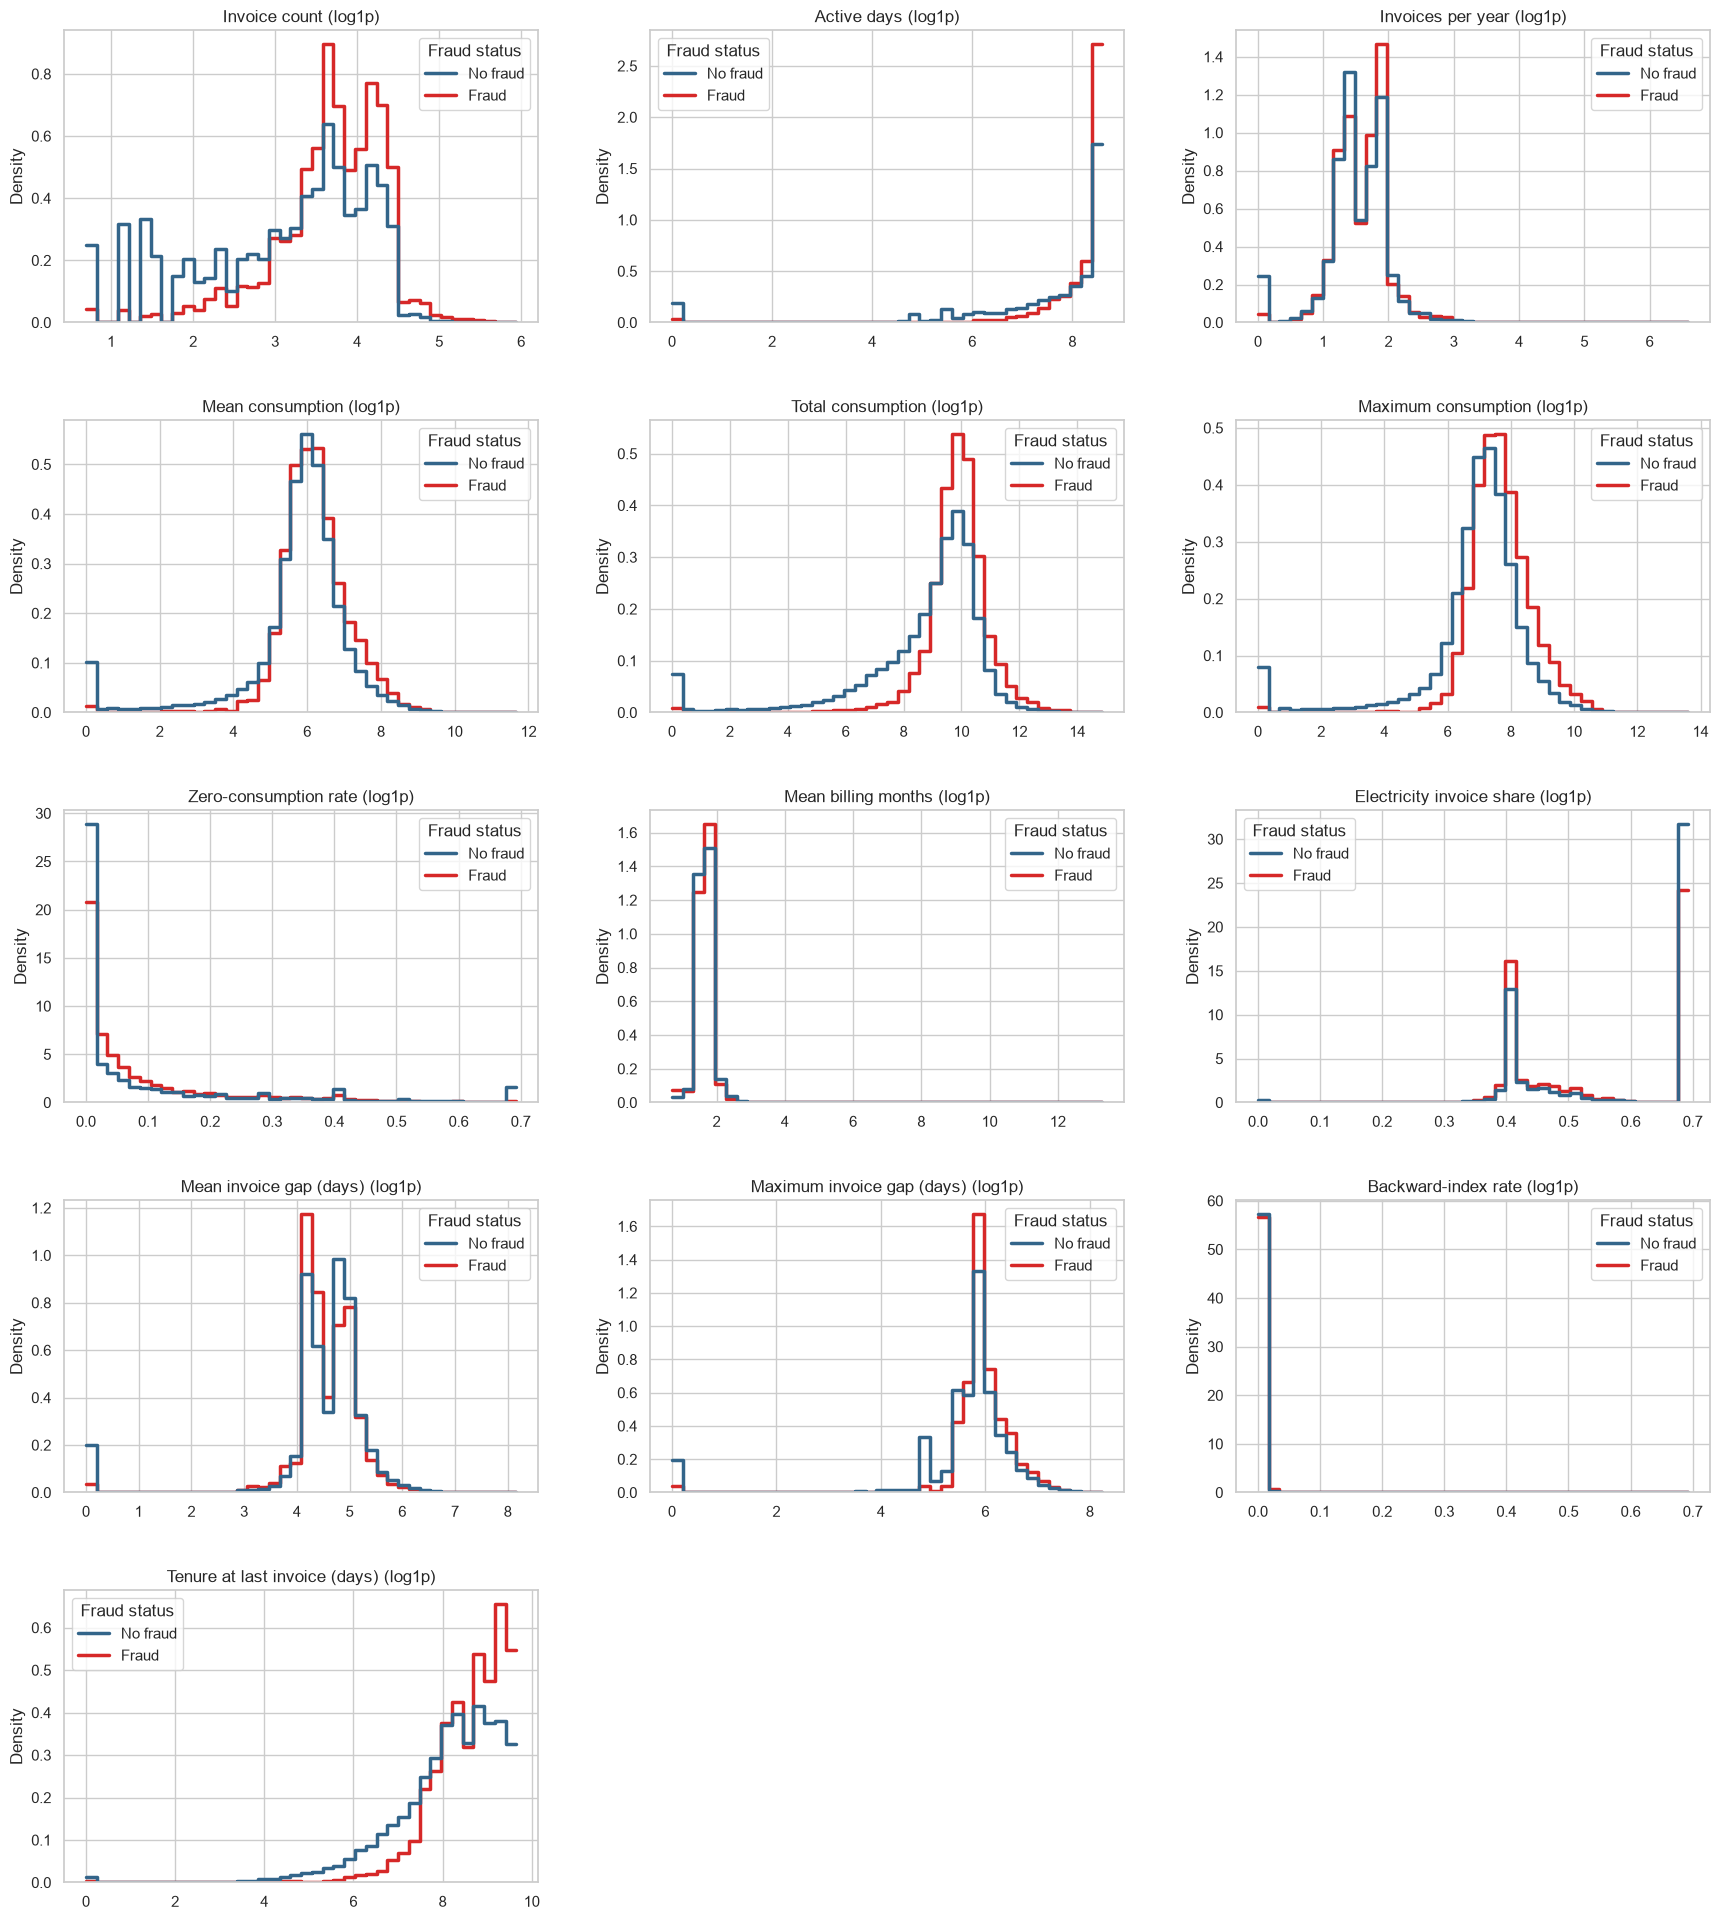

target                                                  0             1
invoice_count                        median          29.0          41.0
                                     mean       32.339092     46.472989
active_days                          median        3286.0        4739.0
                                     mean     2973.785795   3997.584008
invoice_frequency_per_year           median      3.471384      4.093256
                                     mean        4.302588      4.304541
mean_consumption                     median    393.257143         469.0
                                     mean      640.279714    771.546954
total_consumption_sum                median       11557.0       19887.0
                                     mean    18792.168662  32057.144061
total_consumption_max                median        1284.0        2010.0
                                     mean     2235.049794   3543.457459
zero_consumption_rate                median      0.017544      0.037975
                                     mean        0.127785      0.106461
mean_months                          median           4.2      4.210526
                                     mean       31.728445     52.300647
elec_share                           median           1.0      0.641791
                                     mean        0.789927      0.735988
mean_invoice_gap_days                median         114.4     90.333333
                                     mean       117.79744    111.004599
max_invoice_gap_days                 median         351.0         366.0
                                     mean      374.344388    439.909301
backwards_index_rate                 median           0.0           0.0
                                     mean        0.000538      0.001072
customer_tenure_days_at_last_invoice median        4036.0        6303.0
                                     mean      5155.24991   6878.158103

In [9]:
eda_features = [
    "invoice_count",
    "active_days",
    "invoice_frequency_per_year",
    "mean_consumption",
    "total_consumption_sum",
    "total_consumption_max",
    "zero_consumption_rate",
    "mean_months",
    "elec_share",
    "mean_invoice_gap_days",
    "max_invoice_gap_days",
    "backwards_index_rate",
    "customer_tenure_days_at_last_invoice",
]

# Labels keep charts readable without changing the real column names in df_train.
feature_labels = {
    "invoice_count": "Invoice count",
    "active_days": "Active days",
    "invoice_frequency_per_year": "Invoices per year",
    "mean_consumption": "Mean consumption",
    "total_consumption_sum": "Total consumption",
    "total_consumption_max": "Maximum consumption",
    "zero_consumption_rate": "Zero-consumption rate",
    "mean_months": "Mean billing months",
    "elec_share": "Electricity invoice share",
    "mean_invoice_gap_days": "Mean invoice gap (days)",
    "max_invoice_gap_days": "Maximum invoice gap (days)",
    "backwards_index_rate": "Backward-index rate",
    "customer_tenure_days_at_last_invoice": "Tenure at last invoice (days)",
}

# Plot distributions separately for each class. Density lets us compare shapes despite class imbalance.
plot_data = df_train[eda_features + ["target"]].copy()
plot_data["Fraud status"] = plot_data["target"].map({0: "No fraud", 1: "Fraud"})
class_palette = {"No fraud": "#33658A", "Fraud": "#D62828"}
fig, ax = plt.subplots(5, 3, figsize=(18, 20))
for count, feature in enumerate(eda_features):
    plot_frame = pd.DataFrame({
        "value": np.log1p(plot_data[feature].clip(lower=0)),
        "Fraud status": plot_data["Fraud status"],
    })
    sns.histplot(
        data=plot_frame,
        x="value",
        hue="Fraud status",
        hue_order=["No fraud", "Fraud"],
        palette=class_palette,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        bins=40,
        linewidth=2.5,
        ax=ax[int(count / 3)][count % 3],
    )
    ax[int(count / 3)][count % 3].set(title=f"{feature_labels[feature]} (log1p)", xlabel="")
for empty_ax in ax.flat[len(eda_features):]:
    empty_ax.set_visible(False)
fig.tight_layout(pad=3)
plt.show()

summary_by_target = df_train.groupby("target")[eda_features].agg(["median", "mean"])
display(summary_by_target.T)

### Look at relationships between features

The pairplot uses a small random sample of training clients because drawing all clients would be slow and unreadable. Blue points are non-fraud; red points are fraud and deliberately less transparent so they stay visible. It helps us see whether the two groups overlap.

The heatmap and tables below make the next decision explicit. First, we rank each feature by its simple linear relationship with the fraud target. Then, we list feature pairs that are strongly correlated with each other. For a regularised logistic regression, pairs above `0.70` are worth comparing, and pairs above `0.90` are usually candidates to reduce to one feature. We do **not** drop a feature from the heatmap alone: we keep the version that gives the better cross-validation result and is easier to explain.

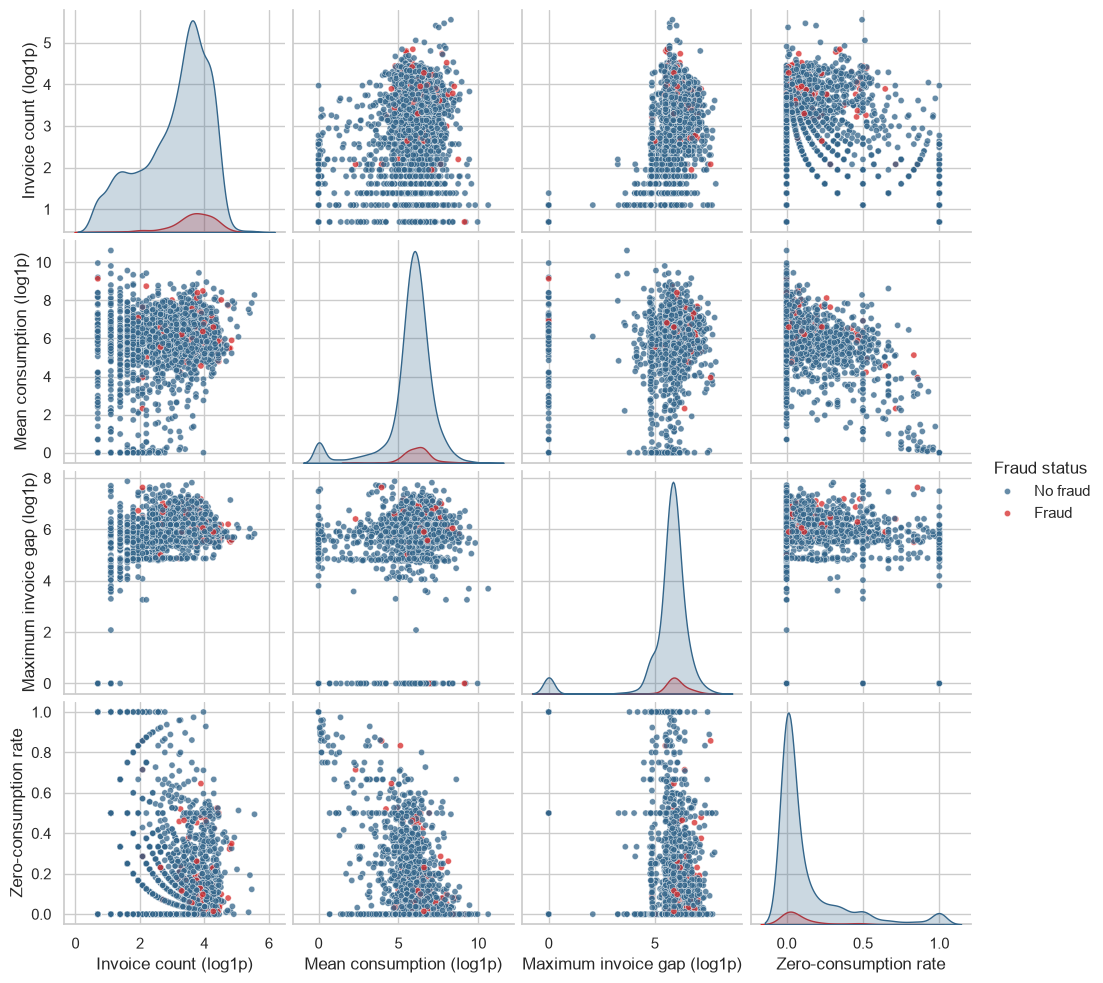

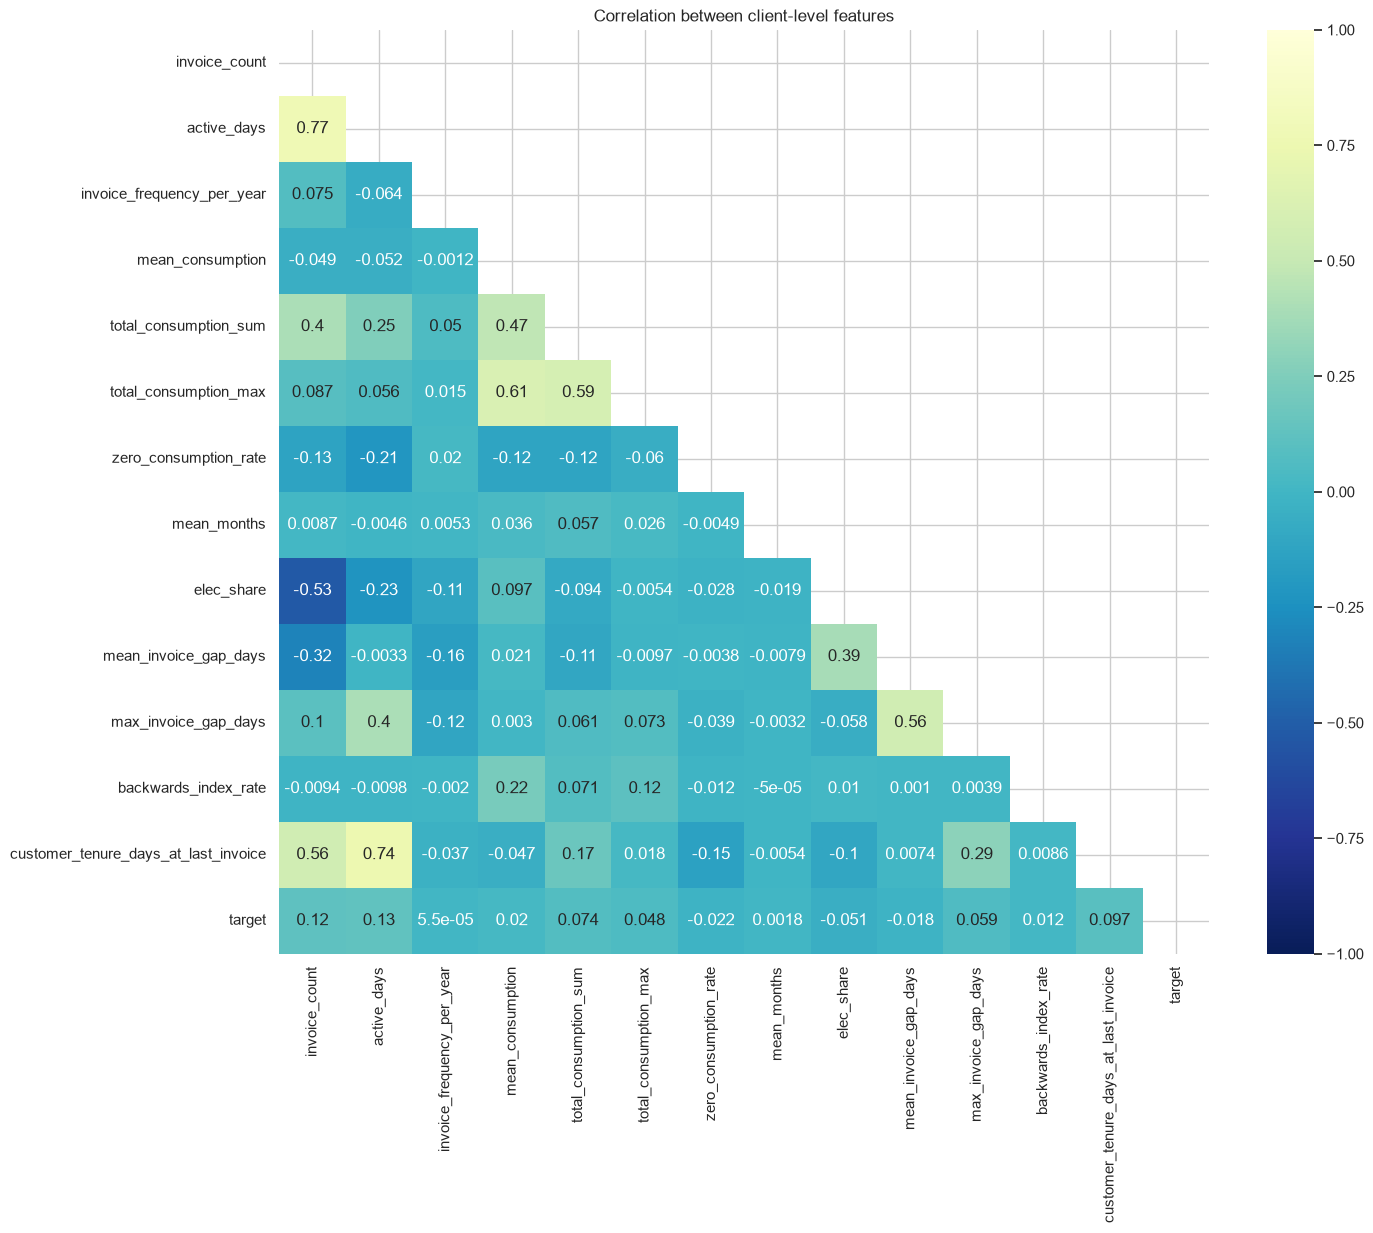

,correlation_with_fraud,absolute_correlation
Active days,0.127225,0.127225
Invoice count,0.124565,0.124565
Tenure at last invoice (days),0.097218,0.097218
Total consumption,0.073616,0.073616
Maximum invoice gap (days),0.058555,0.058555
Electricity invoice share,-0.051292,0.051292
Maximum consumption,0.048447,0.048447
Zero-consumption rate,-0.021784,0.021784
Mean consumption,0.020101,0.020101
Mean invoice gap (days),-0.017534,0.017534


,feature_1,feature_2,correlation,recommended next step
1,Invoice count,Active days,0.769789,Compare both against one feature in cross-vali...
25,Active days,Tenure at last invoice (days),0.742884,Compare both against one feature in cross-vali...


In [10]:
# Pairplot: use a sample so the plot stays readable and fast
pairplot_columns = ["invoice_count", "mean_consumption", "max_invoice_gap_days", "zero_consumption_rate", "target"]
pairplot_data = df_train[pairplot_columns].sample(n=min(3_000, len(df_train)), random_state=RSEED).copy()
pairplot_data["invoice_count"] = np.log1p(pairplot_data["invoice_count"])
pairplot_data["mean_consumption"] = np.log1p(pairplot_data["mean_consumption"].clip(lower=0))
pairplot_data["max_invoice_gap_days"] = np.log1p(pairplot_data["max_invoice_gap_days"])
pairplot_data["Fraud status"] = pairplot_data["target"].map({0: "No fraud", 1: "Fraud"})
pairplot_data = pairplot_data.rename(columns={
    "invoice_count": "Invoice count (log1p)",
    "mean_consumption": "Mean consumption (log1p)",
    "max_invoice_gap_days": "Maximum invoice gap (log1p)",
    "zero_consumption_rate": "Zero-consumption rate",
})
sns.pairplot(
    pairplot_data.drop(columns="target"),
    hue="Fraud status",
    hue_order=["No fraud", "Fraud"],
    palette=class_palette,
    plot_kws={"s": 20, "alpha": 0.75},
)
plt.show()

# Correlation between numeric client-level features
corr = df_train[eda_features + ["target"]].corr(numeric_only=True)
plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap="YlGnBu_r", mask=mask, vmax=1, vmin=-1)
plt.title("Correlation between client-level features")
plt.show()

# Which individual numeric features have the strongest simple relationship with the fraud target?
# This is an EDA clue, not proof that a feature will be useful on its own.
target_correlations = (
    corr["target"]
    .drop("target")
    .rename("correlation_with_fraud")
    .to_frame()
    .assign(absolute_correlation=lambda table: table["correlation_with_fraud"].abs())
    .sort_values("absolute_correlation", ascending=False)
)
target_correlations.index = target_correlations.index.map(feature_labels)
display(target_correlations)

# Which pairs carry very similar information? Show only correlations of 0.70 or more.
feature_pair_correlations = (
    corr.drop(index="target", columns="target")
    .where(np.triu(np.ones((len(eda_features), len(eda_features)), dtype=bool), k=1))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
feature_pair_correlations["absolute_correlation"] = feature_pair_correlations["correlation"].abs()
strong_feature_pairs = feature_pair_correlations.loc[
    feature_pair_correlations["absolute_correlation"].ge(0.70)
].copy()
strong_feature_pairs["recommended next step"] = np.where(
    strong_feature_pairs["absolute_correlation"].ge(0.90),
    "Test keeping only one in logistic regression",
    "Compare both against one feature in cross-validation",
)
strong_feature_pairs["feature_1"] = strong_feature_pairs["feature_1"].map(feature_labels)
strong_feature_pairs["feature_2"] = strong_feature_pairs["feature_2"].map(feature_labels)
strong_feature_pairs = strong_feature_pairs.sort_values("absolute_correlation", ascending=False)
display(strong_feature_pairs[["feature_1", "feature_2", "correlation", "recommended next step"]])

### What these correlations tell us

- No single numeric feature has a strong linear relationship with fraud. The largest target correlations are **active days (0.127)** and **invoice count (0.125)**. **This means the baseline should combine several features.** We should not expect one simple rule to identify fraud.
- **Invoice count and active days correlate at 0.770.** They both describe how much history we have for a client, so a **logistic-regression baseline** should compare using both against using only one.
- **Active days and tenure at last invoice correlate at 0.743.** Tenure is also affected by the unreliable creation dates found in Step 4, so active days is the safer version to try first.
- No pair exceeds 0.90, so the EDA does not justify automatically dropping any feature. We will make the final choice with cross-validation: prefer the smaller, easier-to-explain set if performance is the same.
- Backward-index rate, mean billing months, and invoices per year have almost **no *linear* correlation with fraud**. Keep them for now as possible non-linear signals, but do not expect them to carry the first logistic-regression model alone.

### Fraud rate by client category, region, and district

The correlations above only look at numeric invoice-history features. `client_catg`, `region`, and `disrict` are categorical, so we check them separately: for each category, what share of clients are labelled fraud? We only trust categories with at least 50 clients, since smaller groups give noisy rates.

In [11]:
def fraud_rate_by_group(frame, column, minimum_clients=50):
    result = frame.groupby(column, dropna=False)["target"].agg(clients="size", fraud_rate="mean")
    return result.query("clients >= @minimum_clients").sort_values("fraud_rate", ascending=False)

display(fraud_rate_by_group(df_train, "client_catg"))
display(fraud_rate_by_group(df_train, "region").head(20))
display(fraud_rate_by_group(df_train, "disrict"))

,clients,fraud_rate
client_catg,,
51,1299,0.169361
11,105216,0.054726
12,1879,0.039915


,clients,fraud_rate
region,,
103,7144,0.102744
372,510,0.096078
311,9966,0.080273
106,578,0.079585
371,1639,0.076266
313,1658,0.075995
304,3056,0.070353
379,467,0.068522
107,7990,0.065582


,clients,fraud_rate
disrict,,
69,27391,0.070936
63,23207,0.064894
62,32336,0.052016
60,25460,0.036214


`client_catg == 51` stands out clearly: a fraud rate around **17%**, roughly 3x the overall base rate, on a large enough group of clients to trust (not noise). `region` and `disrict` fraud rates vary by roughly 2-3x across categories too. Worth encoding all three as categorical features, and worth checking model performance per-category later rather than trusting one global score.

### Check the target and remaining data-quality questions

First, this cell shows the fraud/non-fraud balance in `df_train`. Then it compares fraud rates for clients with short and long invoice histories. Finally, it collects the data-quality checks in one table: duplicates, missing values, clients without invoices, and unusual date/index values. These results tell us what needs attention before modelling.

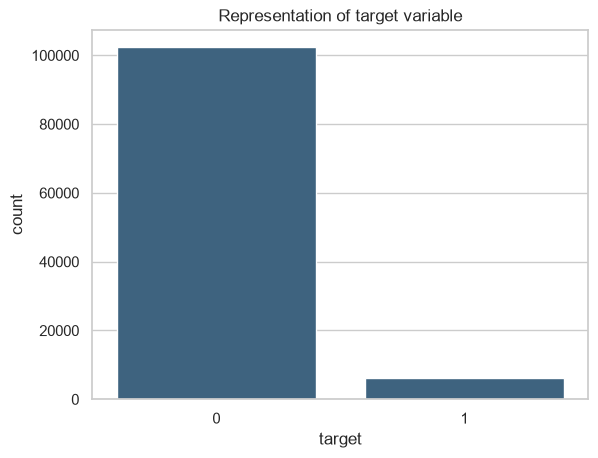

target,not_fraud,fraud
invoice_count_group,,
"(0.999, 7.0]",0.990605,0.009395
"(7.0, 22.0]",0.962872,0.037128
"(22.0, 36.0]",0.932741,0.067259
"(36.0, 57.0]",0.923580,0.076420
"(57.0, 380.0]",0.909875,0.090125


,count
duplicate_client_rows,0
duplicate_client_ids,0
missing_client_cells,0
missing_invoice_cells,0
duplicate_invoice_row_hash_matches,11
clients_without_invoices,0
invoice_clients_without_client_row,0
clients_with_backwards_index,1816
creation_after_first_invoice,8748
negative_customer_tenure,397


,creation_date,first_invoice,last_invoice
min,1977-02-05,1977-06-09,1977-06-16
max,2019-09-10,2019-12-07,2019-12-07


In [12]:
# Representation of the target variable in the training data
sns.countplot(x=df_train["target"], color="#33658A").set_title("Representation of target variable")
plt.show()

# Check whether the fraud rate changes with the amount of invoice history
df_train["invoice_count_group"] = pd.qcut(df_train["invoice_count"], q=5, duplicates="drop")
history_table = pd.crosstab(
    df_train["invoice_count_group"],
    df_train["target"],
    normalize="index",
).rename(columns={0: "not_fraud", 1: "fraud"})
display(history_table)

quality_checks = pd.Series({
    "duplicate_client_rows": int(client.duplicated().sum()),
    "duplicate_client_ids": int(client["client_id"].duplicated().sum()),
    "missing_client_cells": int(client.isna().sum().sum()),
    "missing_invoice_cells": int(invoice_audit["missing_by_column"].sum()),
    "duplicate_invoice_row_hash_matches": invoice_audit["duplicate_row_hash_matches"],
    "clients_without_invoices": len(clients_without_invoices),
    "invoice_clients_without_client_row": len(unknown_invoice_clients),
    "clients_with_backwards_index": int(analysis["backwards_index_count"].gt(0).sum()),
    "creation_after_first_invoice": int(analysis["creation_date"].gt(analysis["first_invoice"]).sum()),
    "negative_customer_tenure": int(analysis["customer_tenure_days_at_last_invoice"].lt(0).sum()),
}, name="count")
display(quality_checks.to_frame())

display(analysis[["creation_date", "first_invoice", "last_invoice"]].agg(["min", "max"]))

In [13]:
# Name the pattern explicitly and quantify it, since it's the single biggest modelling risk here.
observation_window_ratio = history_table["fraud"].iloc[-1] / history_table["fraud"].iloc[0]
print(
    f"Observation-window bias: fraud rate is {observation_window_ratio:.1f}x higher in the "
    f"longest-history quintile ({history_table['fraud'].iloc[-1]:.1%}) than the shortest-history "
    f"quintile ({history_table['fraud'].iloc[0]:.1%}). This is a strong signal that invoice-history "
    "length itself is confounded with the label and needs explicit handling before modelling, not "
    "just treated as a normal feature."
)

Observation-window bias: fraud rate is 9.6x higher in the longest-history quintile (9.0%) than the shortest-history quintile (0.9%). This is a strong signal that invoice-history length itself is confounded with the label and needs explicit handling before modelling, not just treated as a normal feature.


### Inspect the records that need a closer look

The checklist above counts potential data problems. This next cell shows examples, but does **not** delete or correct anything. 
- A duplicate hash is only a signal that two invoice rows have the same values; we inspect it before deciding whether it is a real duplicate.
- A backward index is a negative change in a meter reading. The date examples help us decide whether account-creation dates are reliable enough to use as a model feature.

In [14]:
# First, summarise what each unusual pattern means and what we will decide later.
unusual_records_summary = pd.DataFrame([
    {
        "check": "Duplicate-looking invoice rows",
        "count": invoice_audit["duplicate_row_hash_matches"],
        "meaning": "Two or more invoice rows have the same values in every checked column.",
        "next step": "Inspect the matching rows; only remove them if they are true duplicates.",
    },
    {
        "check": "Clients with a backward meter index",
        "count": int(analysis["backwards_index_count"].gt(0).sum()),
        "meaning": "At least one invoice has a meter index lower than the previous reading.",
        "next step": "Keep it as a possible signal; investigate whether it is a reset or correction.",
    },
    {
        "check": "Creation date after first invoice",
        "count": int(analysis["creation_date"].gt(analysis["first_invoice"]).sum()),
        "meaning": "The recorded account-creation date is later than the first invoice date.",
        "next step": "Do not assume creation_date is a reliable start-of-service date.",
    },
    {
        "check": "Negative customer tenure",
        "count": int(analysis["customer_tenure_days_at_last_invoice"].lt(0).sum()),
        "meaning": "The last invoice is dated before the recorded account-creation date.",
        "next step": "Do not use negative tenure as-is; handle it explicitly during modelling.",
    },
])
display(unusual_records_summary)

# Read only the rows whose hashes matched, so we can inspect the possible invoice duplicates.
duplicate_hashes = set(invoice_audit["duplicate_row_hashes"])
duplicate_invoice_examples = []
if duplicate_hashes:
    invoice_file = pq.ParquetFile(PARQUET_DIR / "invoice_train.parquet")
    for batch in invoice_file.iter_batches(batch_size=CHUNK_SIZE):
        invoice_chunk = batch.to_pandas()
        # Apply the same data types and optional date filter used in aggregate_invoices.
        invoice_chunk["client_id"] = invoice_chunk["client_id"].astype("string")
        invoice_chunk["counter_statue"] = invoice_chunk["counter_statue"].astype("string")
        invoice_chunk["invoice_date"] = pd.to_datetime(invoice_chunk["invoice_date"], errors="raise")
        if AS_OF_DATE is not None:
            invoice_chunk = invoice_chunk.loc[invoice_chunk["invoice_date"].le(pd.Timestamp(AS_OF_DATE))].copy()
        row_hash = pd.util.hash_pandas_object(invoice_chunk, index=False)
        matches = invoice_chunk.loc[row_hash.isin(duplicate_hashes)]
        if not matches.empty:
            duplicate_invoice_examples.append(matches)

if duplicate_invoice_examples:
    duplicate_invoice_examples = pd.concat(duplicate_invoice_examples, ignore_index=True)
    print("Potential duplicate invoice rows (all matching rows are shown):")
    display(duplicate_invoice_examples.sort_values(["client_id", "invoice_date"]))
else:
    print("No matching invoice rows were found to display.")

# Show the clients with the most backward readings, then a small sample of each date issue.
backwards_index_examples = (
    analysis.loc[analysis["backwards_index_count"].gt(0), [
        "client_id", "target", "backwards_index_count", "index_delta_min", "invoice_count"
    ]]
    .sort_values(["backwards_index_count", "index_delta_min"], ascending=[False, True])
    .head(10)
)
display(backwards_index_examples)

creation_after_first_invoice_examples = (
    analysis.loc[analysis["creation_date"].gt(analysis["first_invoice"]), [
        "client_id", "target", "creation_date", "first_invoice", "last_invoice",
        "customer_tenure_days_at_last_invoice"
    ]]
    .sort_values(["creation_date", "first_invoice"])
    .head(10)
)
display(creation_after_first_invoice_examples)

negative_tenure_examples = (
    analysis.loc[analysis["customer_tenure_days_at_last_invoice"].lt(0), [
        "client_id", "target", "creation_date", "last_invoice",
        "customer_tenure_days_at_last_invoice"
    ]]
    .sort_values("customer_tenure_days_at_last_invoice")
    .head(10)
)
display(negative_tenure_examples)

,check,count,meaning,next step
0,Duplicate-looking invoice rows,11,Two or more invoice rows have the same values ...,Inspect the matching rows; only remove them if...
1,Clients with a backward meter index,1816,At least one invoice has a meter index lower t...,Keep it as a possible signal; investigate whet...
2,Creation date after first invoice,8748,The recorded account-creation date is later th...,Do not assume creation_date is a reliable star...
3,Negative customer tenure,397,The last invoice is dated before the recorded ...,Do not use negative tenure as-is; handle it ex...


Potential duplicate invoice rows (all matching rows are shown):


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_125864,2011-12-12,11,101545,5,413,6,1,0,0,0,0,13680,13680,2,ELEC
1,train_Client_125864,2011-12-12,11,101545,5,413,6,1,0,0,0,0,13680,13680,2,ELEC
2,train_Client_25894,2010-07-13,40,6986740,5,5,6,1,0,0,0,0,0,0,2,GAZ
3,train_Client_25894,2010-07-13,40,6986740,5,5,6,1,0,0,0,0,0,0,2,GAZ
4,train_Client_3636,2012-01-18,40,312650,5,5,6,1,0,0,0,0,623,623,2,GAZ
5,train_Client_3636,2012-01-18,40,312650,5,5,6,1,0,0,0,0,623,623,2,GAZ
6,train_Client_37069,2010-10-11,11,5284,5,413,6,1,0,0,0,0,99429,99429,2,ELEC
7,train_Client_37069,2010-10-11,11,5284,5,413,6,1,0,0,0,0,99429,99429,2,ELEC
8,train_Client_44407,2008-02-28,11,66921,5,203,6,1,0,0,0,0,0,0,2,ELEC
9,train_Client_44407,2008-02-28,11,66921,5,203,6,1,0,0,0,0,0,0,2,ELEC


,client_id,target,backwards_index_count,index_delta_min,invoice_count
35538,train_Client_18075,0,8,-9066,37
28586,train_Client_132271,1,7,-98432,122
120072,train_Client_30534,0,6,-97607,168
59154,train_Client_44553,0,6,-97145,236
65469,train_Client_51676,1,6,-96950,223
18078,train_Client_120453,0,5,-99566,76
87115,train_Client_76088,0,5,-98822,248
44077,train_Client_2772,0,5,-98215,30
113703,train_Client_123305,0,5,-97087,105
70726,train_Client_57595,1,5,-96506,135


,client_id,target,creation_date,first_invoice,last_invoice,customer_tenure_days_at_last_invoice
101602,train_Client_92374,0,1977-09-07,1977-08-11,1977-08-11,-27
43161,train_Client_2671,0,1978-02-21,1978-02-10,1978-04-13,51
121666,train_Client_37666,0,1978-05-11,1978-02-10,1979-03-28,321
24721,train_Client_12800,0,1978-07-04,1978-05-10,1978-07-27,23
132217,train_Client_85087,0,1978-07-04,1978-05-10,1978-07-27,23
27329,train_Client_130872,0,1978-07-29,1978-07-12,1979-07-06,342
16568,train_Client_118735,0,1979-04-16,1979-03-12,1979-09-28,165
51237,train_Client_3572,0,1980-07-21,1980-03-11,1981-02-01,195
47918,train_Client_32021,0,1980-08-23,1980-03-10,1981-05-02,252
32377,train_Client_14583,0,1981-05-09,1981-03-06,1981-03-06,-64


,client_id,target,creation_date,last_invoice,customer_tenure_days_at_last_invoice
65253,train_Client_51425,0,2003-11-27,2003-01-12,-319
103166,train_Client_94107,0,2007-10-29,2007-01-11,-291
31319,train_Client_135314,0,2005-10-28,2005-01-12,-289
70538,train_Client_57381,0,2008-11-24,2008-02-12,-286
130530,train_Client_77457,0,2011-10-22,2011-01-12,-283
97474,train_Client_87779,0,2016-11-17,2016-02-12,-279
15612,train_Client_117666,0,2016-11-17,2016-02-12,-279
83295,train_Client_71809,0,2016-11-17,2016-02-12,-279
116994,train_Client_16424,0,2008-11-15,2008-02-12,-277
53084,train_Client_37803,0,2010-11-12,2010-02-12,-273


## Results

### What we learned

- The data contains **135,493 labelled clients** and **4,476,749 invoice rows**. Each client has invoice data, and every invoice belongs to a client in the client table.
- There are **no missing values** in either source table. This means missing-value imputation is not the first issue to solve for this baseline.
- Fraud is imbalanced: **7,566 clients (5.58%)** are labelled as fraud. A model that predicts `not fraud` for everyone would be about 94% accurate but would find no fraud, so accuracy should not be our main metric.
- Fraud clients tend to have more invoice history. The median fraud client has **41 invoices** compared with **29** for a non-fraud client, and **4,739 active days** compared with **3,286**. This is a useful signal, but it may partly reflect how long a client has been observed, so we need to check it carefully.
- The strongest simple pattern is invoice count: the fraud rate rises from **0.9%** for clients with 1–7 invoices to **9.01%** for clients with 58–380 invoices — nearly a 10x range (see the "observation-window bias" note below Step 3's history table). Invoice count should be in the first model, but we should check that it would be available at the point we want to make a prediction.
- Consumption also differs. Median mean consumption is **469** for fraud clients and **393** for non-fraud clients; median maximum consumption is **2,010** versus **1,284**. These are promising features, but the distributions are right-skewed, so using `log1p` is sensible for visualisation and may help a linear baseline.
- The invoice features are related to each other: invoice count, active days, total consumption, and invoice frequency describe overlapping parts of a client’s history. For a simple linear model, we should avoid adding every highly related feature without checking the result.
- `client_catg`, `region`, and `disrict` are also worth using: `client_catg == 51` has a fraud rate around 3x the base rate on a large enough group to trust, and `region`/`disrict` fraud rates vary by roughly 2-3x across categories.

### Data-quality decisions

- There are **11 duplicate-looking invoice row hashes**. This is tiny compared with 4.5 million invoices. We will inspect the displayed rows before deciding whether they are true duplicates; we will not remove them automatically.
- **1,816 clients** have at least one backward meter index. This could be a correction or meter reset, but it could also be useful behaviour. Keep `backwards_index_count` / `backwards_index_rate` as features for now.
- **8,748 clients** have a creation date later than their first invoice and **397 clients** have negative tenure at their last invoice. Therefore, `creation_date` is not always a trustworthy start-of-service date. Do not use raw creation date as a feature. If we use tenure, add a flag for invalid values and decide whether to clip or set those values to missing inside the modelling pipeline.

### Next steps for the baseline

1. Keep `df_test` untouched. Develop the model with stratified cross-validation inside `df_train`.
2. Start with a DummyClassifier, then a regularised logistic regression using the client features already created. This gives us an honest baseline that is easy to explain.
3. Report **PR-AUC** as the main ranking metric because fraud is rare. Also report recall, precision, and a confusion matrix at a business-chosen threshold or review capacity.
4. Compare the baseline with and without the questionable date-derived tenure feature. Keep the backward-index feature, but document its meaning as uncertain.
5. Add `client_catg`, `region`, and `disrict` as categorical features, and flag `client_catg == 51` specifically given its outsized fraud rate.
6. After choosing the approach using only `df_train`, evaluate it once on `df_test` and use the false positives and false negatives for error analysis.

## Step 4 — Decide what to do with the unusual data

The earlier checklist and examples tell us *what* looks unusual. Here we decide whether each issue should be dropped, kept, or changed before modelling. The fraud-rate comparison uses only `df_train`, so `df_test` remains untouched for final model evaluation.

For each client-level issue, compare the fraud rate for clients with the issue to clients without it. A difference does not prove fraud, but it tells us whether the issue could contain useful information.

In [15]:
# Create clear yes/no flags only in the training data for this comparison.
decision_data = df_train.assign(
    has_backward_index=df_train["backwards_index_count"].gt(0),
    creation_after_first_invoice=df_train["creation_date"].gt(df_train["first_invoice"]),
    has_negative_tenure=df_train["customer_tenure_days_at_last_invoice"].lt(0),
)

# For each issue, show how many clients it affects and whether its fraud rate differs.
issue_labels = {
    "has_backward_index": "At least one backward meter index",
    "creation_after_first_invoice": "Creation date after first invoice",
    "has_negative_tenure": "Negative customer tenure",
}
fraud_rate_tables = []
for issue, label in issue_labels.items():
    comparison = (
        decision_data.groupby(issue)["target"]
        .agg(clients="size", fraud_cases="sum", fraud_rate="mean")
        .reset_index()
        .rename(columns={issue: "has_issue"})
    )
    comparison.insert(0, "issue", label)
    comparison["group"] = comparison["has_issue"].map({False: "No", True: "Yes"})
    fraud_rate_tables.append(comparison[["issue", "group", "clients", "fraud_cases", "fraud_rate"]])

issue_fraud_rates = pd.concat(fraud_rate_tables, ignore_index=True)
issue_fraud_rates["fraud_rate"] = issue_fraud_rates["fraud_rate"].map(lambda rate: f"{rate:.2%}")
display(issue_fraud_rates)

# The duplicate check is invoice-level, not client-level. Its scale tells us whether it can materially change the aggregates.
duplicate_impact = pd.DataFrame({
    "duplicate-looking invoice rows": [invoice_audit["duplicate_row_hash_matches"]],
    "all invoice rows": [invoice_audit["invoice_rows"]],
})
duplicate_impact["share of invoice rows"] = (
    duplicate_impact["duplicate-looking invoice rows"] / duplicate_impact["all invoice rows"]
).map(lambda share: f"{share:.5%}")
display(duplicate_impact)

# Final decision table for the baseline. These actions preserve the raw data and make the modelling choices explicit.
model_data_quality_decisions = pd.DataFrame([
    {
        "issue": "Duplicate-looking invoice rows",
        "decision": "Keep for now",
        "why": "Only 11 matches in more than 4.4 million invoice rows; without a unique invoice ID we cannot prove they are accidental duplicates.",
        "model action": "Do not delete automatically. Revisit only if inspection confirms true duplicates.",
    },
    {
        "issue": "Backward meter index",
        "decision": "Keep and model",
        "why": "It may represent a correction or reset, but it is also potentially useful behaviour. The comparison above shows its fraud rate.",
        "model action": "Keep backwards_index_count and backwards_index_rate; do not drop the affected invoices.",
    },
    {
        "issue": "Creation date after first invoice",
        "decision": "Do not use raw creation date",
        "why": "The date cannot consistently represent the start of a customer's service history.",
        "model action": "Do not model creation_date directly. Keep a validity flag only if it improves cross-validation.",
    },
    {
        "issue": "Negative customer tenure",
        "decision": "Manipulate before modelling",
        "why": "Negative tenure is not meaningful as duration, but the invalid-date flag could be informative.",
        "model action": "Replace negative tenure with missing values and add a negative-tenure indicator inside the model pipeline.",
    },
])
display(model_data_quality_decisions)

,issue,group,clients,fraud_cases,fraud_rate
0,At least one backward meter index,No,106951,5893,5.51%
1,At least one backward meter index,Yes,1443,160,11.09%
2,Creation date after first invoice,No,101463,5693,5.61%
3,Creation date after first invoice,Yes,6931,360,5.19%
4,Negative customer tenure,No,108090,6048,5.60%
5,Negative customer tenure,Yes,304,5,1.64%


,duplicate-looking invoice rows,all invoice rows,share of invoice rows
0,11,4476749,0.00025%


,issue,decision,why,model action
0,Duplicate-looking invoice rows,Keep for now,Only 11 matches in more than 4.4 million invoi...,Do not delete automatically. Revisit only if i...
1,Backward meter index,Keep and model,"It may represent a correction or reset, but it...",Keep backwards_index_count and backwards_index...
2,Creation date after first invoice,Do not use raw creation date,The date cannot consistently represent the sta...,Do not model creation_date directly. Keep a va...
3,Negative customer tenure,Manipulate before modelling,"Negative tenure is not meaningful as duration,...",Replace negative tenure with missing values an...


### Step 4 result

We will **not drop raw invoice records** for the baseline. The duplicate-looking rows are too few to materially affect the data and need confirmation first. We will **keep backward-index behaviour** as an aggregated feature, not as a reason to delete records. We will **not use raw `creation_date`** as a predictor. Before modelling, we will change negative tenure values to missing and add a flag that records that the tenure was invalid.

The fraud-rate table above is the final check: if a validity flag has a different fraud rate, test it in cross-validation; if it does not improve the model, leave it out. This lets the model use a data-quality signal only when it earns its place, without treating an unreliable date as a real duration.

## Step 5 — Look for a pattern in meter submissions

This step is different from simply comparing invoice dates. For each physical meter (`client_id` + `counter_number`), we sort its readings by invoice date and compare the current `new_index` with the previous `new_index`. This gives the change in the submitted meter reading between two submissions.

We also calculate a monthly version: `(current new index − previous new index) / days between submissions × 30.44`. This lets us compare clients even when they submit readings at different intervals. Readings on the same day are excluded from this sequence calculation because we cannot reliably tell which one came first. `months_number` is kept separately as the invoice's billing-period length; it is not used as a substitute for the meter submission itself.

In [16]:
def aggregate_meter_submissions(path, chunk_size=250_000, as_of_date=None):
    """Create one set of meter-submission features per client without loading all invoices at once."""
    client_summaries = []
    closed_client_ids = set()
    carry_over = pd.DataFrame()
    cutoff = pd.Timestamp(as_of_date) if as_of_date is not None else None

    def summarise_complete_clients(readings):
        # These clients have all their readings in this batch, so vectorised groupby is safe and fast.
        completed_ids = set(readings["client_id"].unique())
        if completed_ids & closed_client_ids:
            raise ValueError("Invoice clients are not stored together; cannot stream meter submissions safely.")
        closed_client_ids.update(completed_ids)

        readings = readings.sort_values(["client_id", "counter_number", "invoice_date"], kind="stable").copy()
        meter_group = readings.groupby(["client_id", "counter_number"], observed=True)
        readings["previous_new_index"] = meter_group["new_index"].shift()
        readings["previous_submission_date"] = meter_group["invoice_date"].shift()
        readings["submission_gap_days"] = (
            readings["invoice_date"] - readings["previous_submission_date"]
        ).dt.days
        readings["submission_index_delta"] = readings["new_index"] - readings["previous_new_index"]

        # A zero-day gap has no reliable submission order, so it cannot be normalised per month.
        transitions = readings.loc[readings["submission_gap_days"].gt(0)].copy()
        transitions["monthly_submission_index_delta"] = (
            transitions["submission_index_delta"] / transitions["submission_gap_days"] * 30.44
        )

        client_summary = readings.groupby("client_id", observed=True).agg(
            meter_count=("counter_number", "nunique"),
        )
        transition_summary = transitions.groupby("client_id", observed=True).agg(
            submission_transition_count=("submission_index_delta", "size"),
            mean_submission_index_delta=("submission_index_delta", "mean"),
            median_submission_index_delta=("submission_index_delta", "median"),
            mean_monthly_submission_index_delta=("monthly_submission_index_delta", "mean"),
            median_monthly_submission_index_delta=("monthly_submission_index_delta", "median"),
            median_submission_gap_days=("submission_gap_days", "median"),
            backward_submission_count=("submission_index_delta", lambda values: values.lt(0).sum()),
        )
        client_summary = client_summary.join(transition_summary, how="left").reset_index()
        client_summary[["submission_transition_count", "backward_submission_count"]] = (
            client_summary[["submission_transition_count", "backward_submission_count"]].fillna(0).astype("int64")
        )
        client_summaries.append(client_summary)

    invoice_file = pq.ParquetFile(path)
    for batch in invoice_file.iter_batches(
        batch_size=chunk_size,
        columns=["client_id", "counter_number", "invoice_date", "new_index"],
    ):
        readings_chunk = batch.to_pandas()
        readings_chunk["client_id"] = readings_chunk["client_id"].astype("string")
        readings_chunk["invoice_date"] = pd.to_datetime(readings_chunk["invoice_date"], errors="raise")
        if cutoff is not None:
            readings_chunk = readings_chunk.loc[readings_chunk["invoice_date"].le(cutoff)].copy()
        if readings_chunk.empty:
            continue

        combined = pd.concat([carry_over, readings_chunk], ignore_index=True)
        last_client_id = combined["client_id"].iloc[-1]
        complete_clients = combined.loc[combined["client_id"].ne(last_client_id)].copy()
        carry_over = combined.loc[combined["client_id"].eq(last_client_id)].copy()
        if not complete_clients.empty:
            summarise_complete_clients(complete_clients)

    if not carry_over.empty:
        summarise_complete_clients(carry_over)

    submission_features = pd.concat(client_summaries, ignore_index=True)
    submission_features["backward_submission_rate"] = np.where(
        submission_features["submission_transition_count"].gt(0),
        submission_features["backward_submission_count"] / submission_features["submission_transition_count"],
        np.nan,
    )
    return submission_features


submission_features = aggregate_meter_submissions(
    PARQUET_DIR / "invoice_train.parquet",
    chunk_size=CHUNK_SIZE,
    as_of_date=AS_OF_DATE,
)

# Add the new features safely if this cell is run more than once.
submission_feature_columns = [column for column in submission_features.columns if column != "client_id"]
df_train = df_train.drop(columns=submission_feature_columns, errors="ignore").merge(
    submission_features, on="client_id", how="left", validate="one_to_one"
)
df_test = df_test.drop(columns=submission_feature_columns, errors="ignore").merge(
    submission_features, on="client_id", how="left", validate="one_to_one"
)
analysis = pd.concat([df_train, df_test], ignore_index=True)

meter_submission_features = [
    "meter_count",
    "submission_transition_count",
    "mean_monthly_submission_index_delta",
    "median_monthly_submission_index_delta",
    "median_submission_gap_days",
    "backward_submission_rate",
]
monthly_submission_summary = df_train.groupby("target")[meter_submission_features].agg(["median", "mean"])
display(monthly_submission_summary.T)

# Does a higher monthly meter increase correspond to a higher fraud rate?
monthly_delta_data = df_train.dropna(subset=["mean_monthly_submission_index_delta"]).copy()
monthly_delta_data["monthly_delta_group"] = pd.qcut(
    monthly_delta_data["mean_monthly_submission_index_delta"], q=5, duplicates="drop"
)
monthly_delta_fraud_rate = pd.crosstab(
    monthly_delta_data["monthly_delta_group"],
    monthly_delta_data["target"],
    normalize="index",
).rename(columns={0: "not_fraud", 1: "fraud"})
display(monthly_delta_fraud_rate)

# Check that the raw billing-period field supports the same conclusion rather than driving it.
billing_period_summary = df_train.groupby("target")[[
    "mean_billing_months", "four_month_bill_rate", "invoice_frequency_per_year"
]].agg(["median", "mean"])
display(billing_period_summary.T)

target                                                 0            1
meter_count                           median    2.000000     2.000000
                                      mean      1.665540     2.313068
submission_transition_count           median   27.000000    38.000000
                                      mean     30.473349    43.754502
mean_monthly_submission_index_delta   median  106.281567   128.995277
                                      mean    562.121722  1050.109082
median_monthly_submission_index_delta median   68.485241    68.743667
                                      mean    455.432649   582.186317
median_submission_gap_days            median  122.000000   121.500000
                                      mean    134.650518   126.122772
backward_submission_rate              median    0.088235     0.117647
                                      mean      0.129813     0.143205

target,not_fraud,fraud
monthly_delta_group,,
"(-402095.907, 31.526]",0.963505,0.036495
"(31.526, 81.648]",0.941176,0.058824
"(81.648, 139.768]",0.942614,0.057386
"(139.768, 267.437]",0.938439,0.061561
"(267.437, 1207465.754]",0.926002,0.073998


target                                    0         1
mean_billing_months        median       4.2  4.207792
                           mean    4.439967  4.326634
four_month_bill_rate       median  0.843137  0.836364
                           mean    0.764932  0.769173
invoice_frequency_per_year median  3.471384  4.093256
                           mean    4.302588  4.304541

### Step 5 result

- Fraud clients have more meter-reading transitions: a median of **38** compared with **27** for non-fraud clients. They also have a slightly higher median backward-submission rate: **11.76%** compared with **8.82%**. Keep `submission_transition_count` and `backward_submission_rate` as candidate features.
- The typical timing is almost the same: median time between consecutive readings is **121.5 days** for fraud clients and **122 days** for non-fraud clients. Therefore, invoice timing alone does not explain the fraud pattern.
- The typical *median* monthly meter change is also almost identical: **68.7** for fraud clients and **68.5** for non-fraud clients. But the client-level *mean* monthly change is higher for fraud clients: median **129.0** compared with **106.3**. This tells us that a smaller number of unusually large meter changes, rather than every normal submission, may be the useful pattern.
- This is confirmed by the fifths table: fraud rises from **3.65%** in the lowest monthly-change group to **7.40%** in the highest group. Keep `mean_monthly_submission_index_delta` as a candidate feature. Also compare it with `median_monthly_submission_index_delta`, which is less affected by extreme readings.
- Billing-period length is not the explanation: both groups have a median invoice period of about **4.2 months**, and their four-month-invoice rates are almost identical. `mean_billing_months` is lower priority and can be dropped from the first logistic-regression model if cross-validation shows no value.

For the baseline, keep the sequential meter-submission features and use a scaler that is robust to unusually large values. Do not use the invoice date by itself as a fraud signal. Use cross-validation to compare a small model with `mean_monthly_submission_index_delta`, `median_monthly_submission_index_delta`, `submission_transition_count`, and `backward_submission_rate` against the existing invoice-history features.

## Step 6 — Does the meter index reconcile with the billed consumption?

This step asks a different question from Step 5. Step 5 compared a meter's index **across submissions**. Here we check, **within a single invoice**, whether `new_index − old_index` matches the sum of the reported `consommation_level_1..4`. A systematic mismatch is a direct, physically-motivated signal that the meter and the bill disagree — arguably a more direct fraud signal than any status code, since it doesn't depend on an agent's judgement.

We also use the same invoice pass to check `months_number` for implausible values, and to build a per-calendar-year view of invoice volume and consumption. (An earlier version of the `months_number` check used a fixed "valid" set of `{1, 2, 3, 4, 6, 12}`, which flagged 7% of rows as outliers — but the full-file distribution shows `8, 16, 10, 20, 14, 24, 18` are also common, legitimate multi-period bills. A threshold of 36 months (3 years) is a more defensible "physically implausible" cutoff, and only flags about 0.04% of rows — worth knowing if you re-derive a similar check elsewhere.)

months_number outliers: 1,859 of 4,476,749 rows (0.0415%); largest value seen: 636,624
Clients with at least one large index/consumption mismatch (>10 units): 7,728 of 135,493


,clients,reconciliation_gap_abs_mean,reconciliation_gap_abs_median,share_with_large_mismatch,share_with_months_outlier
target,,,,,
0,102341,76.459175,0.0,0.055638,0.003303
1,6053,126.225897,0.0,0.087064,0.002643


,invoice_year,invoice_count,total_consumption_sum,zero_consumption_count,mean_consumption_per_invoice,zero_consumption_rate
0,1977,10,1062,2,106.200000,0.200000
1,1978,56,4672,14,83.428571,0.250000
2,1979,129,80429,22,623.480620,0.170543
3,1980,158,34486,17,218.265823,0.107595
4,1981,205,50552,34,246.595122,0.165854
5,1982,197,55210,38,280.253807,0.192893
6,1983,157,37217,29,237.050955,0.184713
7,1984,812,128188,83,157.866995,0.102217
8,1985,471,100604,59,213.596603,0.125265
9,1986,422,88652,83,210.075829,0.196682


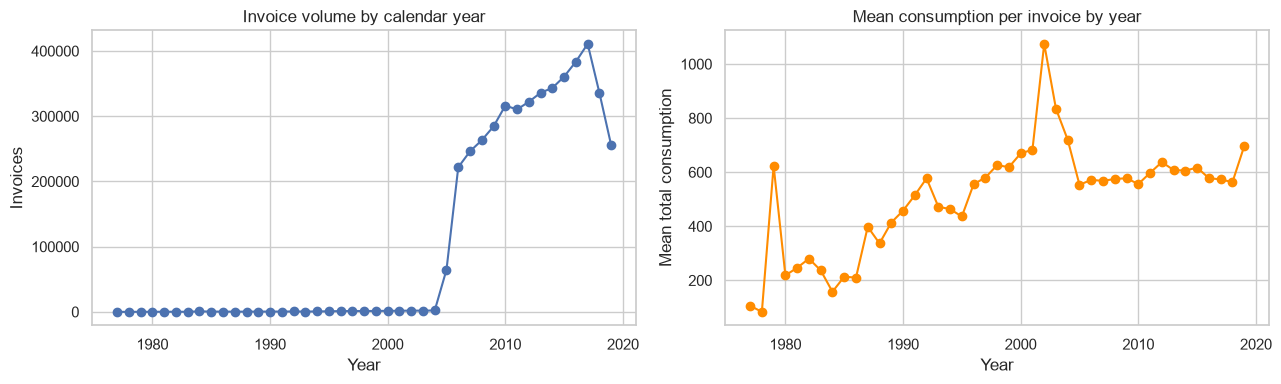

Correlation of reconciliation_gap_abs_mean with target: 0.004 (near zero is expected here -- Pearson correlation is washed out by this heavy-tailed variable's extreme values; the group-mean comparison above is the more trustworthy check)

counter_statue codes outside the expected 0-5 range (see Step 2's counter_status_counts table):


,0
counter_statue,
269375,1
420,1
46,14
618,12
769,6
A,13


Total rows with a genuinely invalid counter_statue code: 47 of 4,476,749 (0.0010%).


In [17]:
def audit_meter_reconciliation(path, chunk_size=250_000, months_number_max_plausible=36, large_mismatch_threshold=10):
    """Check whether new_index - old_index reconciles with reported consumption
    (consommation_level_1..4), and flag months_number values beyond any plausible
    billing period. Also tracks invoice volume/consumption by calendar year to
    check for cohort or recording-practice effects."""
    client_partials = []
    year_partials = []
    months_outlier_rows = 0
    months_max_seen = 0
    total_rows = 0

    parquet_file = pq.ParquetFile(path)
    columns = ["client_id", "invoice_date", "old_index", "new_index", "months_number", *CONSUMPTION_COLUMNS]
    reader = parquet_file.iter_batches(batch_size=chunk_size, columns=columns)

    for batch in reader:
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")
        total_rows += len(chunk)

        chunk["total_consumption"] = chunk[CONSUMPTION_COLUMNS].sum(axis=1)
        chunk["index_delta"] = chunk["new_index"] - chunk["old_index"]
        chunk["reconciliation_gap_abs"] = (chunk["index_delta"] - chunk["total_consumption"]).abs()
        chunk["invoice_year"] = chunk["invoice_date"].dt.year
        chunk["is_months_outlier"] = chunk["months_number"] > months_number_max_plausible

        months_outlier_rows += int(chunk["is_months_outlier"].sum())
        months_max_seen = max(months_max_seen, int(chunk["months_number"].max()))

        client_grouped = chunk.groupby("client_id", observed=True).agg(
            reconciliation_gap_abs_sum=("reconciliation_gap_abs", "sum"),
            reconciliation_gap_abs_max=("reconciliation_gap_abs", "max"),
            row_count=("reconciliation_gap_abs", "size"),
            large_mismatch_count=("reconciliation_gap_abs", lambda s: int((s > large_mismatch_threshold).sum())),
            months_outlier_count=("is_months_outlier", "sum"),
        )
        client_partials.append(client_grouped.reset_index())

        year_grouped = chunk.groupby("invoice_year", observed=True).agg(
            invoice_count=("total_consumption", "size"),
            total_consumption_sum=("total_consumption", "sum"),
            zero_consumption_count=("total_consumption", lambda s: int((s == 0).sum())),
        )
        year_partials.append(year_grouped.reset_index())

    client_partial = pd.concat(client_partials, ignore_index=True)
    client_recon = client_partial.groupby("client_id", as_index=False).agg(
        reconciliation_gap_abs_sum=("reconciliation_gap_abs_sum", "sum"),
        reconciliation_gap_abs_max=("reconciliation_gap_abs_max", "max"),
        row_count=("row_count", "sum"),
        large_mismatch_count=("large_mismatch_count", "sum"),
        months_outlier_count=("months_outlier_count", "sum"),
    )
    client_recon["reconciliation_gap_abs_mean"] = client_recon["reconciliation_gap_abs_sum"] / client_recon["row_count"]

    year_partial = pd.concat(year_partials, ignore_index=True)
    year_trend = year_partial.groupby("invoice_year", as_index=False).agg(
        invoice_count=("invoice_count", "sum"),
        total_consumption_sum=("total_consumption_sum", "sum"),
        zero_consumption_count=("zero_consumption_count", "sum"),
    )
    year_trend["mean_consumption_per_invoice"] = year_trend["total_consumption_sum"] / year_trend["invoice_count"]
    year_trend["zero_consumption_rate"] = year_trend["zero_consumption_count"] / year_trend["invoice_count"]

    audit = {
        "total_rows": total_rows,
        "months_outlier_rows": months_outlier_rows,
        "months_outlier_share": months_outlier_rows / total_rows,
        "months_max_seen": months_max_seen,
    }
    return client_recon, year_trend, audit


meter_recon, year_trend, meter_audit = audit_meter_reconciliation(PARQUET_DIR / "invoice_train.parquet", chunk_size=CHUNK_SIZE)

print(
    f"months_number outliers: {meter_audit['months_outlier_rows']:,} of {meter_audit['total_rows']:,} rows "
    f"({meter_audit['months_outlier_share']:.4%}); largest value seen: {meter_audit['months_max_seen']:,}"
)
print(f"Clients with at least one large index/consumption mismatch (>10 units): "
      f"{(meter_recon['large_mismatch_count'] > 0).sum():,} of {len(meter_recon):,}")

# Add the new features safely if this cell is run more than once.
reconciliation_feature_columns = [column for column in meter_recon.columns if column != "client_id"]
df_train = df_train.drop(columns=reconciliation_feature_columns, errors="ignore").merge(
    meter_recon, on="client_id", how="left", validate="one_to_one"
)
df_test = df_test.drop(columns=reconciliation_feature_columns, errors="ignore").merge(
    meter_recon, on="client_id", how="left", validate="one_to_one"
)
analysis = pd.concat([df_train, df_test], ignore_index=True)

recon_summary = df_train.groupby("target").agg(
    clients=("client_id", "size"),
    reconciliation_gap_abs_mean=("reconciliation_gap_abs_mean", "mean"),
    reconciliation_gap_abs_median=("reconciliation_gap_abs_mean", "median"),
    share_with_large_mismatch=("large_mismatch_count", lambda s: (s > 0).mean()),
    share_with_months_outlier=("months_outlier_count", lambda s: (s > 0).mean()),
)
display(recon_summary)

display(year_trend)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(year_trend["invoice_year"], year_trend["invoice_count"], marker="o")
axes[0].set(title="Invoice volume by calendar year", xlabel="Year", ylabel="Invoices")
axes[1].plot(year_trend["invoice_year"], year_trend["mean_consumption_per_invoice"], marker="o", color="darkorange")
axes[1].set(title="Mean consumption per invoice by year", xlabel="Year", ylabel="Mean total consumption")
plt.tight_layout()
plt.show()

# Single-number correlation check, not a second full heatmap (Step 3 already has one).
reconciliation_correlation = df_train[["reconciliation_gap_abs_mean", "target"]].corr().iloc[0, 1]
print(f"Correlation of reconciliation_gap_abs_mean with target: {reconciliation_correlation:.3f} "
      "(near zero is expected here -- Pearson correlation is washed out by this heavy-tailed "
      "variable's extreme values; the group-mean comparison above is the more trustworthy check)")

# Does the counter_statue dirty-code finding show up in the counts already printed in Step 2?
print("\ncounter_statue codes outside the expected 0-5 range (see Step 2's counter_status_counts table):")
dirty_codes = invoice_audit["counter_status_counts"].loc[
    ~invoice_audit["counter_status_counts"].index.isin(["0", "1", "2", "3", "4", "5"])
]
display(dirty_codes.to_frame())
print(f"Total rows with a genuinely invalid counter_statue code: {dirty_codes.sum():,} of "
      f"{invoice_audit['invoice_rows']:,} ({dirty_codes.sum() / invoice_audit['invoice_rows']:.4%}).")

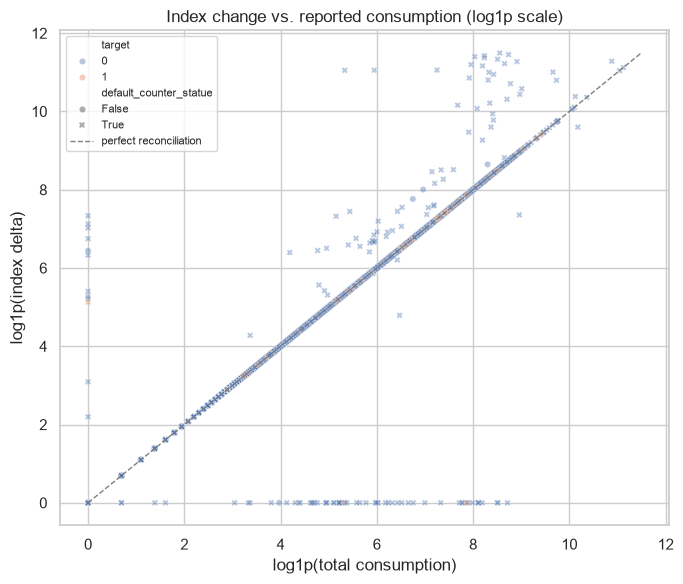

In this sample, 0.6% of invoices have an index/consumption gap larger than 10 units.


In [18]:
row_group_indices = sorted(set([0, max(invoice_parquet.num_row_groups // 2, 0), invoice_parquet.num_row_groups - 1]))
scatter_columns = ["client_id", "old_index", "new_index", *CONSUMPTION_COLUMNS, "counter_statue"]
scatter_frames = []
for row_group in row_group_indices:
    row_group_df = invoice_parquet.read_row_group(row_group, columns=scatter_columns).to_pandas()
    scatter_frames.append(row_group_df.sample(n=min(15_000, len(row_group_df)), random_state=RSEED))

scatter_sample = pd.concat(scatter_frames, ignore_index=True)
scatter_sample["client_id"] = scatter_sample["client_id"].astype("string")
scatter_sample["counter_statue"] = scatter_sample["counter_statue"].astype("string")
scatter_sample["total_consumption"] = scatter_sample[CONSUMPTION_COLUMNS].sum(axis=1)
scatter_sample["index_delta"] = scatter_sample["new_index"] - scatter_sample["old_index"]
scatter_sample = scatter_sample.merge(df_train[["client_id", "target"]], on="client_id", how="inner")
scatter_sample["log1p_index_delta"] = np.log1p(scatter_sample["index_delta"].clip(lower=0))
scatter_sample["log1p_total_consumption"] = np.log1p(scatter_sample["total_consumption"].clip(lower=0))
scatter_sample["default_counter_statue"] = scatter_sample["counter_statue"].eq("0")

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=scatter_sample, x="log1p_total_consumption", y="log1p_index_delta",
    hue="target", style="default_counter_statue", alpha=0.4, s=20, ax=ax,
)
axis_max = scatter_sample[["log1p_total_consumption", "log1p_index_delta"]].to_numpy().max()
ax.plot([0, axis_max], [0, axis_max], color="grey", linestyle="--", linewidth=1, label="perfect reconciliation")
ax.set(title="Index change vs. reported consumption (log1p scale)",
       xlabel="log1p(total consumption)", ylabel="log1p(index delta)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

mismatch_share = ((scatter_sample["index_delta"] - scatter_sample["total_consumption"]).abs() > 10).mean()
print(f"In this sample, {mismatch_share:.1%} of invoices have an index/consumption gap larger than 10 units.")

### Step 6 result

- The reconciliation gap is real signal: mean absolute mismatch between the index change and the billed consumption is **76.5 for non-fraud clients versus 126.2 for fraud clients** — about 65% higher. The *median* gap is 0 for both groups, so this is driven by a subset of invoices with large mismatches, not a uniform shift; a count-based feature (`large_mismatch_count`) is probably more useful than the plain mean.
- Its correlation with `target` looks close to zero on its own — this is expected for a heavy-tailed variable with a handful of extreme values; Pearson correlation is not a reliable way to judge whether a skewed feature carries signal. The group-mean comparison above is the more trustworthy check.
- `months_number` genuinely implausible values (over 36 months) affect only about 0.04% of rows, but include values as large as 636,624 "months" — these must be capped or removed before any `mean`/`sum` aggregate that uses `months_number`, including `mean_months` and `mean_billing_months` above.
- `counter_statue` contains a handful of genuinely invalid codes beyond the expected 0–5 range, but only a tiny fraction of all invoice rows — a cheap cleaning step, not a major blocker.
- The year-by-year view reveals a real cohort effect: invoice volume jumps from roughly 2,000/year before 2005 to over 60,000 in 2005 and 200,000–400,000/year afterward. `creation_date` goes back to 1977, but pre-2005 invoice history is a thin trickle by comparison — treat any "recent vs. historical" feature with caution for clients whose earliest invoice predates 2005.

## Step 7 — Could `reading_remarque` or `counter_statue` leak the outcome of an investigation?

`reading_remarque` is described in the original data dictionary as a note a STEG agent writes **during a physical site visit**. If a visit (or a distinctive note) happens *because* fraud is already suspected, this column risks encoding the outcome of an investigation rather than an independent, available-in-advance predictor. `counter_statue` could carry the same risk.

The check: split each client's invoices into "last invoice ever recorded" versus "earlier invoices," and compare how often each column takes an unusual (non-most-common) value, separately for fraud and non-fraud clients. If unusual codes cluster specifically at fraudulent clients' *last* invoice — more than at their own earlier invoices, and more than at non-fraud clients' last invoice — that's evidence the field is entangled with the investigation itself, not a clean leading indicator.

In [19]:
def audit_last_invoice_leakage(path, last_invoice_lookup, target_lookup, chunk_size=250_000):
    """Compare reading_remarque/counter_statue on each client's LAST invoice against
    their earlier invoices, split by target. Only clients present in target_lookup
    (i.e. df_train) are counted, consistent with the rest of this notebook."""
    counts = {}

    parquet_file = pq.ParquetFile(path)
    columns = ["client_id", "invoice_date", "reading_remarque", "counter_statue"]
    reader = parquet_file.iter_batches(batch_size=chunk_size, columns=columns)

    for batch in reader:
        chunk = batch.to_pandas()
        chunk["client_id"] = chunk["client_id"].astype("string")
        chunk["counter_statue"] = chunk["counter_statue"].astype("string")
        chunk["invoice_date"] = pd.to_datetime(chunk["invoice_date"], errors="raise")

        chunk["target"] = chunk["client_id"].map(target_lookup)
        chunk = chunk.dropna(subset=["target"])
        chunk["last_invoice_date"] = chunk["client_id"].map(last_invoice_lookup)
        chunk["is_last_invoice"] = chunk["invoice_date"].eq(chunk["last_invoice_date"])

        for column in ["reading_remarque", "counter_statue"]:
            grouped = chunk.groupby(["is_last_invoice", "target", column], observed=True).size()
            for (is_last, target, code), row_count in grouped.items():
                key = (column, bool(is_last), int(target), code)
                counts[key] = counts.get(key, 0) + int(row_count)

    result = pd.Series(counts)
    result.index = pd.MultiIndex.from_tuples(result.index, names=["column", "is_last_invoice", "target", "code"])
    return result.rename("rows").reset_index()


last_invoice_lookup = df_train.set_index("client_id")["last_invoice"]
target_lookup = df_train.set_index("client_id")["target"]

leakage_counts = audit_last_invoice_leakage(
    PARQUET_DIR / "invoice_train.parquet", last_invoice_lookup, target_lookup, chunk_size=CHUNK_SIZE
)

leakage_rows = []
for column in ["reading_remarque", "counter_statue"]:
    sub = leakage_counts.query("column == @column")
    modal_code = sub.groupby("code")["rows"].sum().idxmax()
    flagged = sub.assign(is_flagged=sub["code"].ne(modal_code))
    flagged_sum = flagged[flagged["is_flagged"]].groupby(["is_last_invoice", "target"])["rows"].sum()
    total_sum = flagged.groupby(["is_last_invoice", "target"])["rows"].sum()
    rate = (flagged_sum / total_sum).rename("non_modal_code_rate").reset_index()
    rate["column"] = column
    rate["modal_code"] = modal_code
    leakage_rows.append(rate)

leakage_summary = pd.concat(leakage_rows, ignore_index=True)
leakage_pivot = leakage_summary.pivot_table(
    index=["column", "modal_code"], columns=["target", "is_last_invoice"], values="non_modal_code_rate"
)
display(leakage_pivot)

for column in ["reading_remarque", "counter_statue"]:
    rates = leakage_summary.query("column == @column").set_index(["target", "is_last_invoice"])["non_modal_code_rate"]
    fraud_last = rates.get((1, True), float("nan"))
    fraud_earlier = rates.get((1, False), float("nan"))
    honest_last = rates.get((0, True), float("nan"))
    honest_earlier = rates.get((0, False), float("nan"))
    print(
        f"{column}: fraud clients' LAST invoice non-modal-code rate = {fraud_last:.1%} "
        f"(their earlier invoices: {fraud_earlier:.1%}; non-fraud clients' last invoice: {honest_last:.1%}, "
        f"earlier: {honest_earlier:.1%})"
    )

target                              0                   1          
is_last_invoice                 False     True      False     True 
column           modal_code                                        
counter_statue   0           0.022304  0.011409  0.022533  0.002808
reading_remarque 6           0.491145  0.713936  0.505159  0.792936

reading_remarque: fraud clients' LAST invoice non-modal-code rate = 79.3% (their earlier invoices: 50.5%; non-fraud clients' last invoice: 71.4%, earlier: 49.1%)
counter_statue: fraud clients' LAST invoice non-modal-code rate = 0.3% (their earlier invoices: 2.3%; non-fraud clients' last invoice: 1.1%, earlier: 2.2%)


### Step 7 result

- `reading_remarque` shifts toward unusual codes at a client's *last* invoice for **everyone**, not just fraud clients: non-fraud clients go from 49.1% (earlier invoices) to 71.4% (last invoice); fraud clients go from 50.5% to **79.3%**. The shift is somewhat larger for fraud clients, but it's not exclusive to them — this looks like a general end-of-relationship recording pattern (e.g. a different kind of visit right before an account closes) rather than fraud-specific leakage alone.
- `counter_statue` moves in the *opposite* direction — the unusual-status rate *drops* at the last invoice for both groups, and drops further for fraud clients specifically (2.3%→0.3%, versus 2.2%→1.1% for non-fraud).
- Whatever the mechanism, **something changes for everyone right before a client's relationship ends, in both fields, in different directions.** Recommendation: don't use last-invoice-specific values of `reading_remarque`/`counter_statue` as features; if used at all, use only values from invoices before some meaningful cutoff, and say so explicitly in the presentation.

## Optional: save the prepared train and test data

Leave `SAVE_FEATURES = False` while you are still changing the EDA. When you are happy with the client-level features, change it to `True` and run this cell. It writes separate train and test CSV files for the baseline-model notebook.

In [20]:
if SAVE_FEATURES:
    output_dir = DATA_DIR / "processed"
    output_dir.mkdir(parents=True, exist_ok=True)
    train_output_path = output_dir / "train_client_features.csv"
    test_output_path = output_dir / "test_client_features.csv"
    df_train.to_csv(train_output_path, index=False)
    df_test.to_csv(test_output_path, index=False)
    print(f"Saved {len(df_train):,} train rows to {train_output_path}")
    print(f"Saved {len(df_test):,} test rows to {test_output_path}")
else:
    print("Feature saving is disabled. Set SAVE_FEATURES = True when the train and test feature tables are ready to save locally.")

Feature saving is disabled. Set SAVE_FEATURES = True when the train and test feature tables are ready to save locally.
